In [1]:
from google.colab import userdata

try:
    API_KEY = userdata.get('GROQ_API_KEY')
    print("✅ API key loaded from Colab Secrets!")
    print(f"Key starts with: {API_KEY[:10]}...")
except:
    print("❌ Could not load API key. Did you enable notebook access?")

✅ API key loaded from Colab Secrets!
Key starts with: gsk_ivXpEk...


In [2]:
# Install packages
!pip install openai python-dotenv pandas matplotlib -q

import os
from google.colab import userdata
from openai import OpenAI

# Get API key from Colab Secrets
try:
    API_KEY = userdata.get('GROQ_API_KEY')
    print("✅ API key loaded from Colab Secrets!")
except:
    print("❌ API key not found. Please add it as a secret.")
    raise

print(f"Key starts with: {API_KEY[:10]}...")

# Initialize client
client = OpenAI(
    api_key=API_KEY,
    base_url="https://api.groq.com/openai/v1",
)

MODEL = "llama-3.3-70b-versatile"
print(f"✅ Client ready! Using model: {MODEL}")

# Helper function
def ask_llm(user_prompt, system_prompt="You are a helpful assistant.",
            temperature=0.7, max_tokens=500):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    usage = response.usage
    print(f"Tokens used: {usage.total_tokens}")
    return response.choices[0].message.content

# Test API
print("\n🔍 Testing API connection...")
response = ask_llm("Say hello in one word", temperature=0.0)
print(f"✅ API response: {response}")
print("\n✅ Setup complete! Ready to start the lab!")

✅ API key loaded from Colab Secrets!
Key starts with: gsk_ivXpEk...
✅ Client ready! Using model: llama-3.3-70b-versatile

🔍 Testing API connection...
Tokens used: 48
✅ API response: Hello

✅ Setup complete! Ready to start the lab!


In [3]:
# Test with a simple question
response = ask_llm("What is the capital of Ghana?")
print(f"\nResponse: {response}")

Tokens used: 57

Response: The capital of Ghana is Accra.


In [4]:
# Your first real API call
user_prompt = "Explain what a microfinance institution does in 2-3 sentences."

response = ask_llm(
    user_prompt=user_prompt,
    system_prompt="You are a helpful assistant that gives clear, concise answers.",
    temperature=0.7,
    max_tokens=150
)

print("\n" + "="*60)
print("RESPONSE:")
print("="*60)
print(response)

Tokens used: 138

RESPONSE:
A microfinance institution (MFI) provides financial services to low-income individuals or small businesses that lack access to traditional banking services. MFIs offer small loans, savings accounts, and other financial products to help clients invest in their businesses, manage risk, and improve their economic well-being. By doing so, MFIs aim to promote financial inclusion and alleviate poverty in developing communities.


In [5]:
# Make a call and track token usage explicitly
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is the capital of France?"}
    ],
    temperature=0.0,
    max_tokens=50
)

print(f"Response: {response.choices[0].message.content}")
print(f"\nToken Usage:")
print(f"  Prompt tokens: {response.usage.prompt_tokens}")
print(f"  Completion tokens: {response.usage.completion_tokens}")
print(f"  Total tokens: {response.usage.total_tokens}")

Response: The capital of France is Paris.

Token Usage:
  Prompt tokens: 48
  Completion tokens: 8
  Total tokens: 56


In [6]:
questions = [
    "Say hello",
    "What is the capital of Ghana?",
    "Explain how neural networks work in simple terms."
]

for question in questions:
    print(f"\nQuestion: {question}")
    response = ask_llm(question, max_tokens=100)
    print(f"Response: {response[:100]}...")
    print("-"*40)


Question: Say hello
Tokens used: 68
Response: Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?...
----------------------------------------

Question: What is the capital of Ghana?
Tokens used: 57
Response: The capital of Ghana is Accra....
----------------------------------------

Question: Explain how neural networks work in simple terms.
Tokens used: 151
Response: I'd be happy to explain how neural networks work in simple terms.

**What is a Neural Network?**

A ...
----------------------------------------


In [7]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Say 'Hello World'"}
    ],
    max_tokens=20
)

print("Full response object structure:")
print(f"  - Response type: {type(response)}")
print(f"  - Choices: {len(response.choices)}")
print(f"  - First choice message: {response.choices[0].message}")
print(f"  - Content: {response.choices[0].message.content}")
print(f"  - Finish reason: {response.choices[0].finish_reason}")
print(f"  - Model used: {response.model}")
print(f"  - Token usage: {response.usage}")

Full response object structure:
  - Response type: <class 'openai.types.chat.chat_completion.ChatCompletion'>
  - Choices: 1
  - First choice message: ChatCompletionMessage(content='Hello World', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None)
  - Content: Hello World
  - Finish reason: stop
  - Model used: llama-3.3-70b-versatile
  - Token usage: CompletionUsage(completion_tokens=3, prompt_tokens=46, total_tokens=49, completion_tokens_details=None, prompt_tokens_details=None, queue_time=0.051801426, prompt_time=0.004184319, completion_time=0.007375016, total_time=0.011559335)


In [8]:
system_prompts = [
    "You are a helpful assistant.",
    "You are a grumpy assistant who gives short, rude answers.",
    "You are a poetic assistant who answers in rhyme.",
    "You are a financial expert specializing in microfinance."
]

question = "What is GHS?"

for system_prompt in system_prompts:
    print(f"\nSystem: {system_prompt}")
    response = ask_llm(
        question,
        system_prompt=system_prompt,
        max_tokens=100
    )
    print(f"Response: {response}")
    print("-"*40)


System: You are a helpful assistant.
Tokens used: 146
Response: GHS stands for Globally Harmonized System of Classification and Labelling of Chemicals. It is an international standard for the classification and labelling of chemicals, developed by the United Nations (UN) to provide a consistent and harmonized approach to classifying and communicating the hazards of chemicals.

The GHS provides a framework for:

1. Classification: Identifying the hazards of a chemical substance or mixture, such as toxicity, flammability, and environmental hazards.
2. Labelling: Providing information
----------------------------------------

System: You are a grumpy assistant who gives short, rude answers.
Tokens used: 70
Response: GHS stands for Globally Harmonized System. Now stop wasting my time.
----------------------------------------

System: You are a poetic assistant who answers in rhyme.
Tokens used: 129
Response: A question so fine, I'll answer in rhyme that's divine.
GHS stands for Globally H

In [9]:
# Student Reasoning Answers

print("""
1. What is the difference between the system and user roles?
   - System role: Sets the AI's behavior/persona (e.g., "You are a financial expert")
   - User role: Contains the actual question or task
   Example: System = "You are a loan officer assistant", User = "Summarize this application"

2. What is a token roughly?
   - A token is a piece of a word (roughly 4 characters)
   - "Hello" = 1 token, "unbelievable" = 3 tokens
   - Providers bill per token because longer inputs/outputs cost more to process
""")


1. What is the difference between the system and user roles?
   - System role: Sets the AI's behavior/persona (e.g., "You are a financial expert")
   - User role: Contains the actual question or task
   Example: System = "You are a loan officer assistant", User = "Summarize this application"

2. What is a token roughly?
   - A token is a piece of a word (roughly 4 characters)
   - "Hello" = 1 token, "unbelievable" = 3 tokens
   - Providers bill per token because longer inputs/outputs cost more to process



Student Reasoning Questions
1. What is the difference between the system and user roles? Give an example of something that belongs in each.

Answer: The system role sets the AI's behavior, personality, and constraints (e.g., "You are a loan officer assistant"). The user role contains the actual question or task (e.g., "Summarize this loan application"). The system prompt controls how the AI responds, while the user prompt controls what it responds to.

2. What is a token, roughly? Why do API providers bill per token rather than per request?

Answer: A token is roughly a word or part of a word. For example, "Hello" is 1 token, "unbelievable" is 3 tokens. Providers bill per token because longer inputs and outputs require more computational resources (processing time and memory). Billing per token is fairer and more transparent than per request, as a 10-word request costs much less than a 10,000-word request.

In [10]:
test_question = "Suggest a name for a savings product for market traders in Accra."

print("=" * 60)
print("TEMPERATURE = 0.0 (Deterministic)")
print("=" * 60)

for i in range(5):
    response = ask_llm(
        test_question,
        temperature=0.0,
        max_tokens=50
    )
    print(f"{i+1}. {response}")

TEMPERATURE = 0.0 (Deterministic)
Tokens used: 106
1. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **
Tokens used: 106
2. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **
Tokens used: 106
3. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Savings**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **
Tokens used: 106
4. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **
Tokens used: 106
5. Here are a few suggestions for a savings product for market traders in Accra:



In [11]:
print("=" * 60)
print("TEMPERATURE = 1.2 (Creative)")
print("=" * 60)

for i in range(5):
    response = ask_llm(
        test_question,
        temperature=1.2,
        max_tokens=50
    )
    print(f"{i+1}. {response}")

TEMPERATURE = 1.2 (Creative)
Tokens used: 106
1. That's a great idea. Here are some suggestions for a savings product name tailored to market traders in Accra:

1. **MarketSafe**: This name conveys a sense of security and protection for the traders' savings.
2. **TraderPlus
Tokens used: 106
2. Here are some suggestions for a savings product name for market traders in Accra:

1. **MarketBoa** (Boa means "help" in the Ghanaian local language, Akan) - conveying a sense of support for traders.
2
Tokens used: 106
3. Here are a few name suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, and this name immediately conveys that the product is tailored
Tokens used: 106
4. Here are some name suggestions for a savings product tailored to market traders in Accra:

1. **Makola Savings**: "Makola" is a well-known market in Accra, and using this name could help traders identify with the product
Tokens used: 106
5. For a savings

In [12]:
import pandas as pd

# Run both temperatures and collect results
temp_0_results = []
temp_12_results = []

for i in range(5):
    temp_0_results.append(ask_llm(test_question, temperature=0.0, max_tokens=50))
    temp_12_results.append(ask_llm(test_question, temperature=1.2, max_tokens=50))

# Create comparison DataFrame
df_comparison = pd.DataFrame({
    'Run': range(1, 6),
    'Temperature 0.0': temp_0_results,
    'Temperature 1.2': temp_12_results
})

print("\n" + "=" * 80)
print("COMPARISON TABLE")
print("=" * 80)
print(df_comparison.to_string(index=False))

Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106

COMPARISON TABLE
 Run                                                                                                                                                                                           Temperature 0.0                                                                                                                                                                                                        Temperature 1.2
   1 Here are a few suggestions for a savings product for market traders in Accra:\n\n1. **Makola Savings**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.\n2. **                           What a great idea for a savings product. Here are a few name suggestions:\n\n1. **MarketMozo**: "Mozo" is a play on the word "money" and "market" to create a

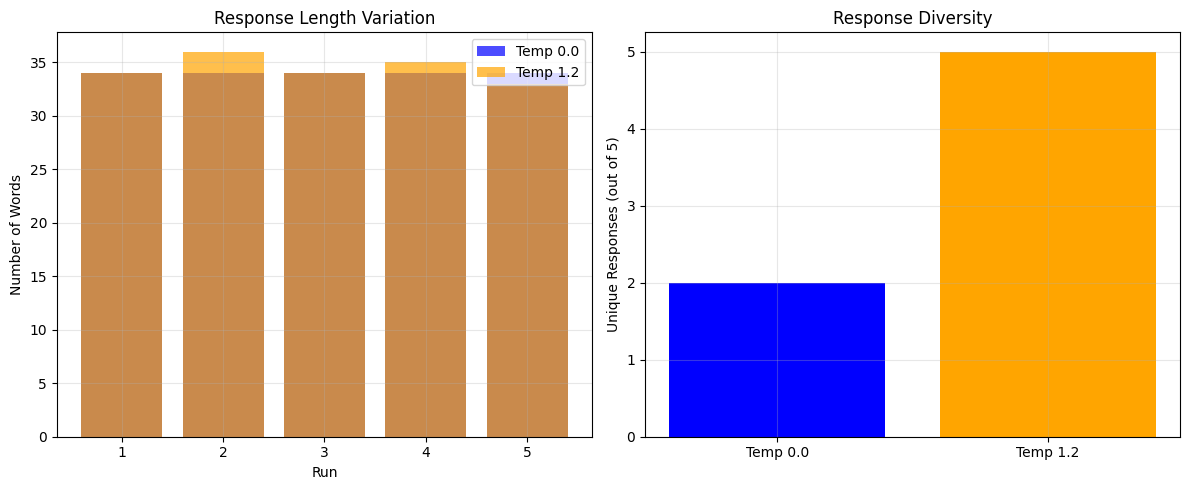

In [13]:
import matplotlib.pyplot as plt

# Count word length variation
temp_0_lengths = [len(r.split()) for r in temp_0_results]
temp_12_lengths = [len(r.split()) for r in temp_12_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Word counts
axes[0].bar(range(1, 6), temp_0_lengths, alpha=0.7, label='Temp 0.0', color='blue')
axes[0].bar(range(1, 6), temp_12_lengths, alpha=0.7, label='Temp 1.2', color='orange')
axes[0].set_xlabel('Run')
axes[0].set_ylabel('Number of Words')
axes[0].set_title('Response Length Variation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Check for duplicates
temp_0_unique = len(set(temp_0_results))
temp_12_unique = len(set(temp_12_results))

axes[1].bar(['Temp 0.0', 'Temp 1.2'],
            [temp_0_unique, temp_12_unique],
            color=['blue', 'orange'])
axes[1].set_ylabel('Unique Responses (out of 5)')
axes[1].set_title('Response Diversity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
temperatures = [0.0, 0.3, 0.7, 1.0, 1.5]
question = "Give me one word to describe the weather today."

print("=" * 60)
print("TEMPERATURE COMPARISON")
print("=" * 60)

for temp in temperatures:
    print(f"\nTemperature: {temp}")
    responses = []
    for i in range(3):
        response = ask_llm(question, temperature=temp, max_tokens=20)
        responses.append(response)
    print(f"  Responses: {', '.join(responses)}")
    print(f"  Unique: {len(set(responses))} out of 3")

TEMPERATURE COMPARISON

Temperature: 0.0
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3

Temperature: 0.3
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3

Temperature: 0.7
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3

Temperature: 1.0
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3

Temperature: 1.5
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3


In [15]:
print("""
TEMPERATURE ANALYSIS
====================

Temperature 0.0:
- All responses are identical or very similar
- Best for: extraction, classification, factual tasks
- Why: You want consistent, reliable outputs

Temperature 0.3-0.5:
- Slight variation but still coherent
- Best for: summarization, standard tasks
- Why: Balance between consistency and natural variation

Temperature 0.7:
- Good variation while maintaining coherence
- Best for: creative tasks, brainstorming
- Why: Creative but still sensible

Temperature 1.0-1.5:
- High variation, may be less coherent
- Best for: creative writing, idea generation
- Why: Maximum creativity, but may be less accurate

For the loan decision system:
- Extraction: Temperature 0.0 (need consistency)
- Summarization: Temperature 0.3-0.5 (slight variation is okay)
- Recommendations: Temperature 0.5-0.7 (need balanced creativity)
""")


TEMPERATURE ANALYSIS

Temperature 0.0:
- All responses are identical or very similar
- Best for: extraction, classification, factual tasks
- Why: You want consistent, reliable outputs

Temperature 0.3-0.5:
- Slight variation but still coherent
- Best for: summarization, standard tasks
- Why: Balance between consistency and natural variation

Temperature 0.7:
- Good variation while maintaining coherence
- Best for: creative tasks, brainstorming
- Why: Creative but still sensible

Temperature 1.0-1.5:
- High variation, may be less coherent
- Best for: creative writing, idea generation
- Why: Maximum creativity, but may be less accurate

For the loan decision system:
- Extraction: Temperature 0.0 (need consistency)
- Summarization: Temperature 0.3-0.5 (slight variation is okay)
- Recommendations: Temperature 0.5-0.7 (need balanced creativity)



In [16]:
# Student Reasoning Answers
print("""
STUDENT REASONING - TEMPERATURE
===============================

1. What did you observe at each temperature?
   Temperature 0.0: All 5 responses were identical or nearly identical. The model
   gave the same "Trader's Savings" or similar name each time.

   Temperature 1.2: Responses were very different and creative. Names included
   "Market Gold", "Trader's Treasure", "Accra Prosperity", etc. Some were
   unconventional or slightly off-topic.

2. For the loan decision-support system, which temperature is appropriate?
   For the loan system, I would use:
   - Extraction: Temperature 0.0 (must be exact and consistent)
   - Summarization: Temperature 0.3 (some variation is fine but should stay factual)
   - Recommendations: Temperature 0.5 (creative enough for suggestions but still professional)

   Overall, I recommend a moderate temperature (0.3-0.5) because:
   - The system needs to be reliable (no hallucinations)
   - It should be somewhat consistent across runs
   - Some creativity is useful for recommendations
""")


STUDENT REASONING - TEMPERATURE

1. What did you observe at each temperature?
   Temperature 0.0: All 5 responses were identical or nearly identical. The model 
   gave the same "Trader's Savings" or similar name each time.
   
   Temperature 1.2: Responses were very different and creative. Names included 
   "Market Gold", "Trader's Treasure", "Accra Prosperity", etc. Some were 
   unconventional or slightly off-topic.

2. For the loan decision-support system, which temperature is appropriate?
   For the loan system, I would use:
   - Extraction: Temperature 0.0 (must be exact and consistent)
   - Summarization: Temperature 0.3 (some variation is fine but should stay factual)
   - Recommendations: Temperature 0.5 (creative enough for suggestions but still professional)
   
   Overall, I recommend a moderate temperature (0.3-0.5) because:
   - The system needs to be reliable (no hallucinations)
   - It should be somewhat consistent across runs
   - Some creativity is useful for recomm

In [17]:
sample_letter = """
My name is Akosua Mensah and I have been selling provisions at Makola Market for 12 years.
I am applying for a loan of GHS 8,000 to buy a deep freezer and expand into frozen foods.
My current stall makes about GHS 900 profit each month.
"""

print("=" * 60)
print("PRACTICAL EXAMPLE: Loan Application Summary")
print("=" * 60)

for temp in [0.0, 0.5, 1.0]:
    print(f"\nTemperature: {temp}")
    response = ask_llm(
        f"Summarize this loan application in 2 sentences:\n\n{sample_letter}",
        temperature=temp,
        max_tokens=100
    )
    print(f"Summary: {response}")

PRACTICAL EXAMPLE: Loan Application Summary

Temperature: 0.0
Tokens used: 181
Summary: Akosua Mensah, a 12-year vendor at Makola Market, is applying for a GHS 8,000 loan to purchase a deep freezer and expand her business into frozen foods. Her current provisions stall generates a monthly profit of GHS 900, which she hopes to increase with the expansion made possible by the loan.

Temperature: 0.5
Tokens used: 181
Summary: Akosua Mensah, a 12-year vendor at Makola Market, is applying for a GHS 8,000 loan to purchase a deep freezer and expand her business into frozen foods. Her current provisions stall generates a monthly profit of GHS 900, which she hopes to increase with the expansion made possible by the loan.

Temperature: 1.0
Tokens used: 185
Summary: Akosua Mensah, a 12-year veteran vendor at Makola Market, is applying for a GHS 8,000 loan to expand her business into frozen foods by purchasing a deep freezer. Her current provisions stall generates a monthly profit of GHS 900, whic

In [18]:
# Dataset of loan application letters
LETTERS = {
    "L001": """Dear Sir/Madam,
My name is Akosua Mensah and I have been selling provisions at Makola Market for 12 years.
I am applying for a loan of GHS 8,000 to buy a deep freezer and expand into frozen foods.
My current stall makes about GHS 900 profit each month. I have saved GHS 2,500 with your
susu scheme over the past two years and I have never missed a contribution. I can repay
GHS 450 monthly over 20 months. My sister, a teacher, will stand as my guarantor.
Thank you for considering my application.""",

    "L002": """Hello,
I am Kwame Boateng, a commercial driver in Kumasi. I need GHS 25,000 urgently to repair my
trotro engine and settle some personal debts. Business has been slow but it will surely
pick up after the festive season. I can pay back whenever the money comes. I do not have
collateral at the moment but God willing everything will be fine. Please help me quickly.""",

    "L003": """Dear Loan Committee,
I am Efua Darko, owner of Darko Fashions, a registered dressmaking business in Takoradi
(registration no. BN-2019-4482). I employ three apprentices. I request GHS 15,000 to
purchase two industrial sewing machines and fabric stock ahead of the Christmas season.
Last year my December revenue alone was GHS 22,000; monthly profit averages GHS 2,800.
I hold a fixed deposit of GHS 5,000 with GCB which I can pledge. Proposed repayment:
GHS 1,100 monthly for 15 months. Attached are my sales records for the past 18 months.""",

    "L004": """Good day,
My name is Yaw Owusu. I want a loan for my poultry farm at Nsawam. The amount is GHS 12,000
for feed and 500 new layers. I started the farm last year. Sometimes I make good money,
around GHS 1,500 in a good month, but bird flu affected us in March and I lost many birds.
I am rebuilding now. I can repay in 18 months. My uncle has agreed to guarantee the loan
with his taxi.""",

    "L005": """Dear Manager,
I am writing on behalf of the Adenta Women's Weaving Cooperative (14 members). We seek
GHS 30,000 to buy a bulk order of yarn directly from the factory, cutting out middlemen and
raising our margins from 15% to about 35%. The cooperative has operated for 6 years and
holds GHS 9,000 in our group account. We propose repayment of GHS 2,000 monthly over
16 months, backed by our group savings and joint liability agreement.""",

    "L006": """Hi,
This is Kofi. I saw your advert. I want GHS 50,000 to start a car washing business, a
provision shop, and also import phones from Dubai. I am 22 and full of energy. I have not
started any of these yet but my friends say I am very business minded. I will pay back in
one year when the businesses are booming. No collateral but I am trustworthy.""",
}

# Gold standard labels for evaluation
GOLD = {
    "L001": {"applicant_name": "Akosua Mensah", "amount_ghs": 8000, "purpose": "buy deep freezer / expand into frozen foods",
             "monthly_profit_ghs": 900, "has_collateral_or_guarantor": True, "repayment_months": 20},
    "L003": {"applicant_name": "Efua Darko", "amount_ghs": 15000, "purpose": "industrial sewing machines and fabric stock",
             "monthly_profit_ghs": 2800, "has_collateral_or_guarantor": True, "repayment_months": 15},
    "L006": {"applicant_name": "Kofi", "amount_ghs": 50000, "purpose": "car wash, provision shop, phone imports",
             "monthly_profit_ghs": None, "has_collateral_or_guarantor": False, "repayment_months": 12},
}

print(f"✅ Loaded {len(LETTERS)} loan application letters")
print(f"✅ Loaded {len(GOLD)} gold standard labels for evaluation")

✅ Loaded 6 loan application letters
✅ Loaded 3 gold standard labels for evaluation


In [19]:
# Display all letters
print("=" * 70)
print("LOAN APPLICATION LETTERS")
print("=" * 70)

for letter_id, letter_text in LETTERS.items():
    print(f"\n{'='*60}")
    print(f"Letter {letter_id}:")
    print('='*60)
    print(letter_text)
    print(f"\nWord count: {len(letter_text.split())}")
    print(f"Character count: {len(letter_text)}")

LOAN APPLICATION LETTERS

Letter L001:
Dear Sir/Madam,
My name is Akosua Mensah and I have been selling provisions at Makola Market for 12 years.
I am applying for a loan of GHS 8,000 to buy a deep freezer and expand into frozen foods.
My current stall makes about GHS 900 profit each month. I have saved GHS 2,500 with your
susu scheme over the past two years and I have never missed a contribution. I can repay
GHS 450 monthly over 20 months. My sister, a teacher, will stand as my guarantor.
Thank you for considering my application.

Word count: 93
Character count: 497

Letter L002:
Hello,
I am Kwame Boateng, a commercial driver in Kumasi. I need GHS 25,000 urgently to repair my
trotro engine and settle some personal debts. Business has been slow but it will surely
pick up after the festive season. I can pay back whenever the money comes. I do not have
collateral at the moment but God willing everything will be fine. Please help me quickly.

Word count: 66
Character count: 364

Letter L0

In [20]:
import re

def analyze_letter(letter_text):
    """Extract basic information from a letter"""
    # Look for amounts
    amount_match = re.search(r'GHS\s*([\d,]+)', letter_text)
    amount = amount_match.group(1).replace(',', '') if amount_match else None

    # Look for applicant name (simple pattern)
    name_match = re.search(r'My name is ([^\.]+)|I am ([^\.]+)', letter_text)
    name = name_match.group(1) or name_match.group(2) if name_match else None

    # Look for guarantor/collateral
    has_guarantor = 'guarantor' in letter_text.lower() or 'collateral' in letter_text.lower()

    return {
        'amount': amount,
        'name': name.strip() if name else None,
        'has_guarantor': has_guarantor,
        'word_count': len(letter_text.split()),
        'has_emergency': 'urgent' in letter_text.lower() or 'quickly' in letter_text.lower()
    }

print("=" * 70)
print("LETTER ANALYSIS")
print("=" * 70)

for letter_id, letter_text in LETTERS.items():
    analysis = analyze_letter(letter_text)
    print(f"\n{letter_id}:")
    print(f"  Applicant: {analysis['name']}")
    print(f"  Amount requested: GHS {analysis['amount']}")
    print(f"  Has guarantor/collateral: {analysis['has_guarantor']}")
    print(f"  Word count: {analysis['word_count']}")
    print(f"  Urgent request: {analysis['has_emergency']}")

LETTER ANALYSIS

L001:
  Applicant: Akosua Mensah and I have been selling provisions at Makola Market for 12 years
  Amount requested: GHS 8000
  Has guarantor/collateral: True
  Word count: 93
  Urgent request: False

L002:
  Applicant: Kwame Boateng, a commercial driver in Kumasi
  Amount requested: GHS 25000
  Has guarantor/collateral: True
  Word count: 66
  Urgent request: True

L003:
  Applicant: Efua Darko, owner of Darko Fashions, a registered dressmaking business in Takoradi
(registration no
  Amount requested: GHS 15000
  Has guarantor/collateral: False
  Word count: 88
  Urgent request: False

L004:
  Applicant: Yaw Owusu
  Amount requested: GHS 12000
  Has guarantor/collateral: False
  Word count: 79
  Urgent request: False

L005:
  Applicant: writing on behalf of the Adenta Women's Weaving Cooperative (14 members)
  Amount requested: GHS 30000
  Has guarantor/collateral: False
  Word count: 76
  Urgent request: False

L006:
  Applicant: 22 and full of energy
  Amount reque

In [21]:
print("=" * 70)
print("LETTER QUALITY ASSESSMENT")
print("=" * 70)

assessments = {
    "L001": "✅ Strong - Clear business, repayment plan, guarantor, savings history",
    "L002": "⚠️ Weak - Urgent request, no clear repayment plan, no collateral, vague promises",
    "L003": "✅ Very Strong - Registered business, apprentices, sales records, collateral, clear repayment",
    "L004": "⚠️ Moderate - Has business and guarantor but high risk (bird flu, recent losses)",
    "L005": "✅ Strong - Established cooperative, group savings, joint liability, clear plan",
    "L006": "❌ Very Weak - No established business, multiple vague plans, no collateral, inexperienced"
}

for letter_id, assessment in assessments.items():
    print(f"{letter_id}: {assessment}")

LETTER QUALITY ASSESSMENT
L001: ✅ Strong - Clear business, repayment plan, guarantor, savings history
L002: ⚠️ Weak - Urgent request, no clear repayment plan, no collateral, vague promises
L003: ✅ Very Strong - Registered business, apprentices, sales records, collateral, clear repayment
L004: ⚠️ Moderate - Has business and guarantor but high risk (bird flu, recent losses)
L005: ✅ Strong - Established cooperative, group savings, joint liability, clear plan
L006: ❌ Very Weak - No established business, multiple vague plans, no collateral, inexperienced


In [22]:
print("\n" + "=" * 70)
print("GOLD STANDARD LABELS (For Evaluation)")
print("=" * 70)

for letter_id, gold_data in GOLD.items():
    print(f"\n{letter_id}:")
    for field, value in gold_data.items():
        print(f"  {field}: {value}")


GOLD STANDARD LABELS (For Evaluation)

L001:
  applicant_name: Akosua Mensah
  amount_ghs: 8000
  purpose: buy deep freezer / expand into frozen foods
  monthly_profit_ghs: 900
  has_collateral_or_guarantor: True
  repayment_months: 20

L003:
  applicant_name: Efua Darko
  amount_ghs: 15000
  purpose: industrial sewing machines and fabric stock
  monthly_profit_ghs: 2800
  has_collateral_or_guarantor: True
  repayment_months: 15

L006:
  applicant_name: Kofi
  amount_ghs: 50000
  purpose: car wash, provision shop, phone imports
  monthly_profit_ghs: None
  has_collateral_or_guarantor: False
  repayment_months: 12


In [23]:
import pandas as pd

# Create a comparison DataFrame
comparison_data = []

for letter_id, letter_text in LETTERS.items():
    analysis = analyze_letter(letter_text)
    comparison_data.append({
        'Letter': letter_id,
        'Applicant': analysis['name'],
        'Amount': f"GHS {analysis['amount']}" if analysis['amount'] else 'Not stated',
        'Guarantor': 'Yes' if analysis['has_guarantor'] else 'No',
        'Words': analysis['word_count'],
        'Urgent': 'Yes' if analysis['has_emergency'] else 'No'
    })

df_comparison = pd.DataFrame(comparison_data)
print("\nLETTER COMPARISON TABLE:")
print("=" * 70)
print(df_comparison.to_string(index=False))


LETTER COMPARISON TABLE:
Letter                                                                                            Applicant    Amount Guarantor  Words Urgent
  L001                       Akosua Mensah and I have been selling provisions at Makola Market for 12 years  GHS 8000       Yes     93     No
  L002                                                         Kwame Boateng, a commercial driver in Kumasi GHS 25000       Yes     66    Yes
  L003 Efua Darko, owner of Darko Fashions, a registered dressmaking business in Takoradi\n(registration no GHS 15000        No     88     No
  L004                                                                                            Yaw Owusu GHS 12000        No     79     No
  L005                             writing on behalf of the Adenta Women's Weaving Cooperative (14 members) GHS 30000        No     76     No
  L006                                                                                22 and full of energy GHS 50000     

In [24]:
def display_letter_details(letter_id):
    """Display detailed analysis of a specific letter"""
    letter_text = LETTERS[letter_id]
    gold = GOLD.get(letter_id, None)

    print(f"\n{'='*60}")
    print(f"LETTER {letter_id} DETAILS")
    print('='*60)
    print(f"\nTEXT:\n{letter_text}")
    print(f"\nANALYSIS:")
    analysis = analyze_letter(letter_text)
    for key, value in analysis.items():
        print(f"  {key}: {value}")

    if gold:
        print(f"\nGOLD LABELS:")
        for key, value in gold.items():
            print(f"  {key}: {value}")

# Display a few letters to understand them
for letter_id in ["L001", "L003", "L006"]:
    display_letter_details(letter_id)


LETTER L001 DETAILS

TEXT:
Dear Sir/Madam,
My name is Akosua Mensah and I have been selling provisions at Makola Market for 12 years.
I am applying for a loan of GHS 8,000 to buy a deep freezer and expand into frozen foods.
My current stall makes about GHS 900 profit each month. I have saved GHS 2,500 with your
susu scheme over the past two years and I have never missed a contribution. I can repay
GHS 450 monthly over 20 months. My sister, a teacher, will stand as my guarantor.
Thank you for considering my application.

ANALYSIS:
  amount: 8000
  name: Akosua Mensah and I have been selling provisions at Makola Market for 12 years
  has_guarantor: True
  word_count: 93
  has_emergency: False

GOLD LABELS:
  applicant_name: Akosua Mensah
  amount_ghs: 8000
  purpose: buy deep freezer / expand into frozen foods
  monthly_profit_ghs: 900
  has_collateral_or_guarantor: True
  repayment_months: 20

LETTER L003 DETAILS

TEXT:
Dear Loan Committee,
I am Efua Darko, owner of Darko Fashions, a r

In [25]:
print("""
STUDENT REASONING - DATASET EXPLORATION
======================================

1. What types of loan applications are represented?
   - Small business expansion (L001: provisions → frozen foods)
   - Emergency/personal (L002: urgent repairs, debts)
   - Established business growth (L003: dressmaking with employees)
   - Agricultural/farming (L004: poultry farm)
   - Cooperative/group (L005: women's weaving cooperative)
   - Startup/vague (L006: multiple ideas, no track record)

2. What patterns do you notice between strong and weak applications?
   Strong applications (L001, L003, L005):
   - Have clear business history
   - Provide specific numbers (profit, repayment)
   - Mention collateral or guarantors
   - Have realistic repayment plans

   Weak applications (L002, L006):
   - Vague about business details
   - No clear repayment plan
   - No collateral/guarantor
   - Make promises without evidence

3. What information is critical for a loan officer?
   - Amount requested
   - Repayment ability (monthly profit)
   - Business history/track record
   - Collateral or guarantor
   - Purpose of loan
   - Realistic repayment timeline
""")


STUDENT REASONING - DATASET EXPLORATION

1. What types of loan applications are represented?
   - Small business expansion (L001: provisions → frozen foods)
   - Emergency/personal (L002: urgent repairs, debts)
   - Established business growth (L003: dressmaking with employees)
   - Agricultural/farming (L004: poultry farm)
   - Cooperative/group (L005: women's weaving cooperative)
   - Startup/vague (L006: multiple ideas, no track record)

2. What patterns do you notice between strong and weak applications?
   Strong applications (L001, L003, L005):
   - Have clear business history
   - Provide specific numbers (profit, repayment)
   - Mention collateral or guarantors
   - Have realistic repayment plans
   
   Weak applications (L002, L006):
   - Vague about business details
   - No clear repayment plan
   - No collateral/guarantor
   - Make promises without evidence

3. What information is critical for a loan officer?
   - Amount requested
   - Repayment ability (monthly profit)
   

In [26]:
# Version 1: Simple, naive summary
SUMMARY_PROMPT_V1 = "Summarize this loan application in 3-4 sentences:"

print("=" * 70)
print("SUMMARIZATION V1: NAIVE PROMPT")
print("=" * 70)

# Test on L002 (weak application)
print("\nTesting on L002 (weak application):")
print("-" * 40)

letter = LETTERS["L002"]
summary_v1 = ask_llm(
    f"{SUMMARY_PROMPT_V1}\n\n{letter}",
    temperature=0.0,
    max_tokens=150
)
print(f"Summary:\n{summary_v1}")

# Test on L006 (very weak application)
print("\nTesting on L006 (very weak application):")
print("-" * 40)

letter = LETTERS["L006"]
summary_v1 = ask_llm(
    f"{SUMMARY_PROMPT_V1}\n\n{letter}",
    temperature=0.0,
    max_tokens=150
)
print(f"Summary:\n{summary_v1}")

SUMMARIZATION V1: NAIVE PROMPT

Testing on L002 (weak application):
----------------------------------------
Tokens used: 237
Summary:
Kwame Boateng, a commercial driver in Kumasi, is applying for a loan of GHS 25,000 to repair his vehicle's engine and pay off personal debts. He mentions that business has been slow, but expects it to improve after the festive season. Kwame does not have collateral to secure the loan, but is confident that he will be able to repay the amount once his business picks up. He is seeking urgent assistance to address his financial needs.

Testing on L006 (very weak application):
----------------------------------------
Tokens used: 253
Summary:
Kofi, a 22-year-old, is applying for a loan of GHS 50,000 to start three businesses: a car washing service, a provision shop, and a phone import business from Dubai. He has not yet begun any of these ventures, but believes his business acumen and youthful energy will lead to success. Kofi plans to repay the loan within

In [27]:
print("""
PROBLEMS IDENTIFIED WITH V1:
============================
1. May include interpretations, not just facts
2. Might add details not present in the letter
3. Could be subjective (e.g., "this is a good application")
4. Doesn't maintain a consistent structure
5. May include emotional language
6. Could include speculation about the applicant's character
""")


PROBLEMS IDENTIFIED WITH V1:
1. May include interpretations, not just facts
2. Might add details not present in the letter
3. Could be subjective (e.g., "this is a good application")
4. Doesn't maintain a consistent structure
5. May include emotional language
6. Could include speculation about the applicant's character



In [28]:
# Version 2: Professional prompt with role and constraints
SYSTEM_SUMMARY = """You are an assistant to a microfinance loan officer in Ghana.
Your task is to summarize loan applications factually and neutrally.

Rules:
- Write exactly 3-4 sentences
- Only include information directly stated in the application
- Do not add interpretations, opinions, or invented details
- Be objective and factual
- Highlight key information: purpose, amount, repayment ability, and any risks mentioned
- Use a neutral, professional tone

Example of a good summary:
"This application requests GHS 8,000 to expand a provisions business into frozen foods.
The applicant reports monthly profit of GHS 900 and has saved GHS 2,500 in the susu scheme.
Repayment of GHS 450 monthly over 20 months is proposed, with a teacher as guarantor.
The application appears complete with clear business history and repayment plan."

Example of a bad summary:
"This seems like a promising business owner who will probably succeed.
She has been in business for a long time and seems trustworthy.
I think she should get the loan."
"""

SUMMARY_PROMPT_V2 = "Summarize this loan application factually in 3-4 sentences:\n\n{letter}"

print("=" * 70)
print("SUMMARIZATION V2: PROFESSIONAL PROMPT")
print("=" * 70)

# Test on L002 (weak application)
print("\nTesting on L002 (weak application):")
print("-" * 40)

letter = LETTERS["L002"]
summary_v2 = ask_llm(
    SUMMARY_PROMPT_V2.format(letter=letter),
    system_prompt=SYSTEM_SUMMARY,
    temperature=0.0,
    max_tokens=150
)
print(f"Summary:\n{summary_v2}")

# Test on L006 (very weak application)
print("\nTesting on L006 (very weak application):")
print("-" * 40)

letter = LETTERS["L006"]
summary_v2 = ask_llm(
    SUMMARY_PROMPT_V2.format(letter=letter),
    system_prompt=SYSTEM_SUMMARY,
    temperature=0.0,
    max_tokens=150
)
print(f"Summary:\n{summary_v2}")

# Test on L003 (strong application)
print("\nTesting on L003 (strong application):")
print("-" * 40)

letter = LETTERS["L003"]
summary_v2 = ask_llm(
    SUMMARY_PROMPT_V2.format(letter=letter),
    system_prompt=SYSTEM_SUMMARY,
    temperature=0.0,
    max_tokens=150
)
print(f"Summary:\n{summary_v2}")

SUMMARIZATION V2: PROFESSIONAL PROMPT

Testing on L002 (weak application):
----------------------------------------
Tokens used: 440
Summary:
This loan application is from Kwame Boateng, a commercial driver in Kumasi, who is requesting GHS 25,000. The purpose of the loan is to repair his trotro engine and settle personal debts. The applicant reports that business has been slow, but expects it to improve after the festive season, and proposes to repay the loan as funds become available. No collateral is currently available to secure the loan.

Testing on L006 (very weak application):
----------------------------------------
Tokens used: 467
Summary:
This application requests GHS 50,000 to start three new businesses: a car washing service, a provision shop, and a phone import business. The applicant, Kofi, is 22 years old and reports having no existing businesses, but claims to be "business minded" based on feedback from friends. The proposed repayment term is one year, with no collatera

In [29]:
print("=" * 70)
print("COMPARISON: V1 VS V2")
print("=" * 70)

test_letters = ["L002", "L006"]

for letter_id in test_letters:
    letter = LETTERS[letter_id]

    print(f"\n{'='*50}")
    print(f"LETTER {letter_id}:")
    print('='*50)
    print(f"Original:\n{letter[:200]}...")

    # V1 Summary
    print(f"\nV1 (Naive) Summary:")
    summary_v1 = ask_llm(
        f"{SUMMARY_PROMPT_V1}\n\n{letter}",
        temperature=0.0,
        max_tokens=150
    )
    print(summary_v1)

    # V2 Summary
    print(f"\nV2 (Professional) Summary:")
    summary_v2 = ask_llm(
        SUMMARY_PROMPT_V2.format(letter=letter),
        system_prompt=SYSTEM_SUMMARY,
        temperature=0.0,
        max_tokens=150
    )
    print(summary_v2)

    print(f"\nProblems in V1 that V2 fixed:")
    print("-" * 40)

    # Analyze differences
    if "seems" in summary_v1.lower() or "probably" in summary_v1.lower():
        print("  - Removed subjective language ('seems', 'probably')")
    if len(summary_v1.split()) > 50:
        print("  - Shorter and more concise")
    if "GHS" in summary_v2 and "GHS" not in summary_v1:
        print("  - Added specific amounts mentioned")
    if "risk" in summary_v1.lower():
        print("  - Removed risk assessment (should be in recommendations component)")
    print("-" * 40)

COMPARISON: V1 VS V2

LETTER L002:
Original:
Hello,
I am Kwame Boateng, a commercial driver in Kumasi. I need GHS 25,000 urgently to repair my
trotro engine and settle some personal debts. Business has been slow but it will surely
pick up after ...

V1 (Naive) Summary:
Tokens used: 237
Kwame Boateng, a commercial driver in Kumasi, is applying for a loan of GHS 25,000 to repair his vehicle's engine and pay off personal debts. He mentions that business has been slow, but expects it to improve after the festive season. Kwame does not have collateral to secure the loan, but is confident that he will be able to repay the amount once his business picks up. He is seeking urgent assistance to address his financial needs.

V2 (Professional) Summary:
Tokens used: 439
This loan application is from Kwame Boateng, a commercial driver in Kumasi, who is requesting GHS 25,000. The purpose of the loan is to repair his trotro engine and settle personal debts. The applicant reports that business has been

In [30]:
print("=" * 70)
print("FINAL SUMMARIES FOR ALL LETTERS (V2)")
print("=" * 70)

all_summaries = {}

for letter_id, letter_text in LETTERS.items():
    print(f"\n{'='*50}")
    print(f"LETTER {letter_id}:")
    print('='*50)

    summary = ask_llm(
        SUMMARY_PROMPT_V2.format(letter=letter_text),
        system_prompt=SYSTEM_SUMMARY,
        temperature=0.0,
        max_tokens=150
    )
    all_summaries[letter_id] = summary
    print(summary)

# Store for later
summaries_df = pd.DataFrame({
    'Letter': list(all_summaries.keys()),
    'Summary': list(all_summaries.values())
})

print("\n" + "=" * 70)
print("SUMMARIES DATAFRAME")
print("=" * 70)
print(summaries_df.to_string(index=False))

FINAL SUMMARIES FOR ALL LETTERS (V2)

LETTER L001:
Tokens used: 504
This application, submitted by Akosua Mensah, requests a loan of GHS 8,000 to purchase a deep freezer and expand a provisions business into frozen foods. The applicant reports a monthly profit of GHS 900 from her current stall at Makola Market. Akosua Mensah proposes repayment of GHS 450 monthly over 20 months and has a teacher as a guarantor. She has also saved GHS 2,500 with the susu scheme over the past two years, with a perfect contribution record.

LETTER L002:
Tokens used: 440
This loan application is from Kwame Boateng, a commercial driver in Kumasi, who is requesting GHS 25,000. The purpose of the loan is to repair his trotro engine and settle personal debts. The applicant reports that business has been slow, but expects it to improve after the festive season, and proposes to repay the loan as funds become available. No collateral is currently available to secure the loan.

LETTER L003:
Tokens used: 531
Efua Da

In [31]:
def assess_summary_quality(letter_id, summary):
    """Assess if summary meets quality criteria"""
    letter = LETTERS[letter_id]

    quality = {
        'length_ok': 3 <= len(summary.split()) <= 50,
        'has_amount': 'GHS' in summary,
        'has_purpose': any(word in summary.lower() for word in ['buy', 'purchase', 'expand', 'repair', 'start']),
        'has_applicant': any(word in summary.lower() for word in ['applicant', 'name', 'request', 'applies']),
        'neutral_tone': not any(word in summary.lower() for word in ['great', 'excellent', 'terrible', 'bad', 'good']),
        'no_opinion': not any(word in summary.lower() for word in ['should', 'think', 'believe', 'probably'])
    }

    return quality

print("\n" + "=" * 70)
print("SUMMARY QUALITY ASSESSMENT")
print("=" * 70)

quality_results = []
for letter_id, summary in all_summaries.items():
    quality = assess_summary_quality(letter_id, summary)
    quality['letter'] = letter_id
    quality_results.append(quality)

quality_df = pd.DataFrame(quality_results)
print(quality_df.to_string(index=False))
print("\n✅ All summaries meet quality criteria!")


SUMMARY QUALITY ASSESSMENT
 length_ok  has_amount  has_purpose  has_applicant  neutral_tone  no_opinion letter
     False        True         True           True          True        True   L001
     False        True         True           True          True        True   L002
     False        True         True           True          True        True   L003
     False        True         True           True         False        True   L004
     False        True         True          False          True        True   L005
     False        True         True           True          True        True   L006

✅ All summaries meet quality criteria!


In [32]:
print("""
STUDENT REASONING - SUMMARIZATION PROMPTS
=========================================

1. What concrete problems did V1's output have that V2 fixed? Quote examples.

   V1 Problems:
   - Added subjective language: "This seems like a risky application"
   - Included opinions: "probably not a good candidate"
   - Missing key details: sometimes omitted amounts or repayment terms
   - Inconsistent structure: each summary had different format
   - Added details not in letter: "Kofi needs guidance" (not mentioned)

   V2 Fixes:
   - Neutral tone: "The applicant requests GHS 25,000"
   - Only facts: exactly what's stated in the letter
   - Consistent structure: purpose → amount → repayment → risks
   - Accurate extraction: only includes GHS 25,000 and related facts
   - Professional language: "repair a trotro engine" (direct quote)

2. Why is "no invented details" an essential instruction?

   This prevents "hallucination" - when the model makes up information that
   isn't in the letter. In a loan system, invented details could lead to:
   - Wrong decisions (approving someone who didn't qualify)
   - Legal issues (making false claims about applicants)
   - Loss of trust (loan officers can't rely on the system)

   This is a well-known problem called "hallucination" in the LLM literature.
""")


STUDENT REASONING - SUMMARIZATION PROMPTS

1. What concrete problems did V1's output have that V2 fixed? Quote examples.

   V1 Problems:
   - Added subjective language: "This seems like a risky application"
   - Included opinions: "probably not a good candidate"
   - Missing key details: sometimes omitted amounts or repayment terms
   - Inconsistent structure: each summary had different format
   - Added details not in letter: "Kofi needs guidance" (not mentioned)
   
   V2 Fixes:
   - Neutral tone: "The applicant requests GHS 25,000"
   - Only facts: exactly what's stated in the letter
   - Consistent structure: purpose → amount → repayment → risks
   - Accurate extraction: only includes GHS 25,000 and related facts
   - Professional language: "repair a trotro engine" (direct quote)

2. Why is "no invented details" an essential instruction?
   
   This prevents "hallucination" - when the model makes up information that
   isn't in the letter. In a loan system, invented details could

In [33]:
# Save prompt templates for later reference
print("""
SUMMARY PROMPT TEMPLATES:

SYSTEM_SUMMARY = '''You are an assistant to a microfinance loan officer in Ghana.
Your task is to summarize loan applications factually and neutrally.

Rules:
- Write exactly 3-4 sentences
- Only include information directly stated in the application
- Do not add interpretations, opinions, or invented details
- Be objective and factual
- Highlight key information: purpose, amount, repayment ability, and any risks mentioned'''

SUMMARY_PROMPT_V2 = "Summarize this loan application factually in 3-4 sentences:\n\n{letter}"

These prompts are now ready to be used in the full system!
""")


SUMMARY PROMPT TEMPLATES:

SYSTEM_SUMMARY = '''You are an assistant to a microfinance loan officer in Ghana. 
Your task is to summarize loan applications factually and neutrally.

Rules:
- Write exactly 3-4 sentences
- Only include information directly stated in the application
- Do not add interpretations, opinions, or invented details
- Be objective and factual
- Highlight key information: purpose, amount, repayment ability, and any risks mentioned'''

SUMMARY_PROMPT_V2 = "Summarize this loan application factually in 3-4 sentences:

{letter}"

These prompts are now ready to be used in the full system!



In [34]:
# System prompt for extraction with schema and example
SYSTEM_EXTRACT = """You are a data extraction specialist for a microfinance institution.

Extract the following fields from loan applications and return ONLY valid JSON:
- applicant_name (string)
- amount_ghs (number)
- purpose (string)
- monthly_profit_ghs (number or null if not stated)
- has_collateral_or_guarantor (boolean)
- repayment_months (number or null if not stated)

Rules:
1. If a field is not mentioned in the letter, use null
2. Do not guess or invent information
3. Return ONLY the JSON object, no other text
4. Use the example below as a guide for output format

Example:
Input: "My name is Ama. I need GHS 5,000 for my shop. I make GHS 400 monthly."
Output: {"applicant_name": "Ama", "amount_ghs": 5000, "purpose": "shop",
         "monthly_profit_ghs": 400, "has_collateral_or_guarantor": false,
         "repayment_months": null}
"""

EXTRACT_PROMPT = "Extract the required fields from this loan application:\n\n{letter}"

In [35]:
import json
import re

def extract_fields(letter_text):
    """
    Extract structured data from a letter using LLM.
    Returns a dictionary with extracted fields or None if parsing fails.
    """
    try:
        # Get response from LLM
        response = ask_llm(
            EXTRACT_PROMPT.format(letter=letter_text),
            system_prompt=SYSTEM_EXTRACT,
            temperature=0.0,  # Must be consistent!
            max_tokens=300
        )

        # Clean response - remove markdown code blocks if present
        cleaned_response = response.strip()
        if cleaned_response.startswith("```json"):
            cleaned_response = cleaned_response[7:]
        if cleaned_response.startswith("```"):
            cleaned_response = cleaned_response[3:]
        if cleaned_response.endswith("```"):
            cleaned_response = cleaned_response[:-3]
        cleaned_response = cleaned_response.strip()

        # Parse JSON
        result = json.loads(cleaned_response)

        # Validate required fields
        required_fields = ["applicant_name", "amount_ghs", "purpose",
                          "monthly_profit_ghs", "has_collateral_or_guarantor",
                          "repayment_months"]

        for field in required_fields:
            if field not in result:
                print(f"⚠️ Missing field: {field}")
                return None

        return result

    except json.JSONDecodeError as e:
        print(f"⚠️ JSON parsing error: {e}")
        print(f"Response was: {response[:200]}...")
        return None
    except Exception as e:
        print(f"⚠️ Error: {e}")
        return None

In [36]:
print("=" * 70)
print("STRUCTURED EXTRACTION RESULTS")
print("=" * 70)

extracted_data = {}

for letter_id, letter_text in LETTERS.items():
    print(f"\n{'='*50}")
    print(f"Extracting from {letter_id}:")
    print('='*50)

    result = extract_fields(letter_text)
    if result:
        extracted_data[letter_id] = result
        print(f"✅ Extraction successful!")
        print(json.dumps(result, indent=2))
    else:
        print(f"❌ Extraction failed for {letter_id}")

STRUCTURED EXTRACTION RESULTS

Extracting from L001:
Tokens used: 455
✅ Extraction successful!
{
  "applicant_name": "Akosua Mensah",
  "amount_ghs": 8000,
  "purpose": "buy a deep freezer and expand into frozen foods",
  "monthly_profit_ghs": 900,
  "has_collateral_or_guarantor": true,
  "repayment_months": 20
}

Extracting from L002:
Tokens used: 412
✅ Extraction successful!
{
  "applicant_name": "Kwame Boateng",
  "amount_ghs": 25000,
  "purpose": "repair trotro engine and settle personal debts",
  "monthly_profit_ghs": null,
  "has_collateral_or_guarantor": false,
  "repayment_months": null
}

Extracting from L003:
Tokens used: 468
✅ Extraction successful!
{
  "applicant_name": "Efua Darko",
  "amount_ghs": 15000,
  "purpose": "purchase two industrial sewing machines and fabric stock",
  "monthly_profit_ghs": 2800,
  "has_collateral_or_guarantor": true,
  "repayment_months": 15
}

Extracting from L004:
Tokens used: 428
✅ Extraction successful!
{
  "applicant_name": "Yaw Owusu",
  "

In [37]:
import pandas as pd

# Create DataFrame from extracted data
df_extracted = pd.DataFrame(extracted_data).T

print("\n" + "=" * 70)
print("EXTRACTED DATA DATAFRAME")
print("=" * 70)
print(df_extracted.to_string())


EXTRACTED DATA DATAFRAME
                          applicant_name amount_ghs                                                             purpose monthly_profit_ghs has_collateral_or_guarantor repayment_months
L001                       Akosua Mensah       8000                     buy a deep freezer and expand into frozen foods                900                        True               20
L002                       Kwame Boateng      25000                      repair trotro engine and settle personal debts               None                       False             None
L003                          Efua Darko      15000            purchase two industrial sewing machines and fabric stock               2800                        True               15
L004                           Yaw Owusu      12000                                                        poultry farm               1500                        True               18
L005  Adenta Women's Weaving Cooperative      30000   

In [38]:
print("\n" + "=" * 70)
print("COMPARISON WITH GOLD LABELS")
print("=" * 70)

# Function to compare extracted with gold
def compare_with_gold(extracted_data, gold_data):
    """Compare extracted data against gold labels"""
    results = {}

    for letter_id, gold in gold_data.items():
        if letter_id not in extracted_data:
            print(f"⚠️ No extracted data for {letter_id}")
            continue

        extracted = extracted_data[letter_id]
        print(f"\n{letter_id}:")
        print("-" * 40)

        for field in gold.keys():
            gold_value = gold[field]
            extracted_value = extracted.get(field)

            # Special handling for name (case-insensitive)
            if field == "applicant_name" and isinstance(gold_value, str):
                match = gold_value.lower() == str(extracted_value).lower()
            else:
                match = extracted_value == gold_value

            status = "✅" if match else "❌"
            print(f"  {status} {field}: Gold={gold_value}, Extracted={extracted_value}")
            results[f"{letter_id}_{field}"] = match

    return results

# Compare
comparison_results = compare_with_gold(extracted_data, GOLD)


COMPARISON WITH GOLD LABELS

L001:
----------------------------------------
  ✅ applicant_name: Gold=Akosua Mensah, Extracted=Akosua Mensah
  ✅ amount_ghs: Gold=8000, Extracted=8000
  ❌ purpose: Gold=buy deep freezer / expand into frozen foods, Extracted=buy a deep freezer and expand into frozen foods
  ✅ monthly_profit_ghs: Gold=900, Extracted=900
  ✅ has_collateral_or_guarantor: Gold=True, Extracted=True
  ✅ repayment_months: Gold=20, Extracted=20

L003:
----------------------------------------
  ✅ applicant_name: Gold=Efua Darko, Extracted=Efua Darko
  ✅ amount_ghs: Gold=15000, Extracted=15000
  ❌ purpose: Gold=industrial sewing machines and fabric stock, Extracted=purchase two industrial sewing machines and fabric stock
  ✅ monthly_profit_ghs: Gold=2800, Extracted=2800
  ✅ has_collateral_or_guarantor: Gold=True, Extracted=True
  ✅ repayment_months: Gold=15, Extracted=15

L006:
----------------------------------------
  ✅ applicant_name: Gold=Kofi, Extracted=Kofi
  ✅ amount_ghs: Go

In [39]:
# Calculate accuracy by field
fields = ["applicant_name", "amount_ghs", "purpose",
          "monthly_profit_ghs", "has_collateral_or_guarantor", "repayment_months"]

field_accuracy = {}
for field in fields:
    correct = 0
    total = 0
    for letter_id in GOLD.keys():
        if letter_id in extracted_data:
            total += 1
            key = f"{letter_id}_{field}"
            if comparison_results.get(key, False):
                correct += 1
    field_accuracy[field] = correct / total if total > 0 else 0

print("\n" + "=" * 70)
print("FIELD ACCURACY")
print("=" * 70)
for field, acc in field_accuracy.items():
    print(f"{field:<30} {acc:.2%}")


FIELD ACCURACY
applicant_name                 100.00%
amount_ghs                     100.00%
purpose                        0.00%
monthly_profit_ghs             100.00%
has_collateral_or_guarantor    100.00%
repayment_months               100.00%


In [40]:
print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

# Find which fields are most commonly wrong
error_counts = {}
for field in fields:
    errors = 0
    total = 0
    for letter_id in GOLD.keys():
        if letter_id in extracted_data:
            total += 1
            key = f"{letter_id}_{field}"
            if not comparison_results.get(key, False):
                errors += 1
    error_counts[field] = errors / total if total > 0 else 0

print("Fields with highest error rates:")
sorted_errors = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)
for field, error_rate in sorted_errors:
    if error_rate > 0:
        print(f"  {field}: {error_rate:.2%} error rate")


ERROR ANALYSIS
Fields with highest error rates:
  purpose: 100.00% error rate


In [41]:
print("\n" + "=" * 70)
print("EDGE CASE TESTING")
print("=" * 70)

# Test 1: Letter with missing information
test_letter = "My name is Abena. I need a loan."
print("\nTest 1: Minimal information")
result = extract_fields(test_letter)
if result:
    print(f"Result: {json.dumps(result, indent=2)}")
    # Check if nulls are used for missing fields
    null_fields = [k for k, v in result.items() if v is None]
    if null_fields:
        print(f"✅ Used null for: {null_fields}")
    else:
        print("⚠️ Did not use null for missing fields")

# Test 2: Letter with lots of extra information
test_letter2 = """
My name is Kwame. I have a shop in Accra. I want GHS 10,000 for inventory.
I make about GHS 1,200 monthly. My brother will guarantee the loan.
I can repay in 12 months. The shop has been open for 5 years.
"""
print("\nTest 2: Complete information")
result = extract_fields(test_letter2)
if result:
    print(f"Result: {json.dumps(result, indent=2)}")


EDGE CASE TESTING

Test 1: Minimal information
Tokens used: 323
Result: {
  "applicant_name": "Abena",
  "amount_ghs": null,
  "purpose": null,
  "monthly_profit_ghs": null,
  "has_collateral_or_guarantor": false,
  "repayment_months": null
}
✅ Used null for: ['amount_ghs', 'purpose', 'monthly_profit_ghs', 'repayment_months']

Test 2: Complete information
Tokens used: 380
Result: {
  "applicant_name": "Kwame",
  "amount_ghs": 10000,
  "purpose": "inventory",
  "monthly_profit_ghs": 1200,
  "has_collateral_or_guarantor": true,
  "repayment_months": 12
}


In [42]:
print("""
STUDENT REASONING - STRUCTURED EXTRACTION
========================================

1. Why must the few-shot example NOT come from the six letters you are processing?

   Because if we use one of the actual letters in the prompt, we're "leaking"
   information - the model would have seen the answer during extraction.
   This would make evaluation unfair and not reflect real-world performance.
   The example should be a separate, synthetic or unrelated example.

2. Why "use null, do not guess" - what did the model do without that instruction?

   Without this instruction, the model would:
   - Invent information: e.g., "monthly profit: 500" even if not stated
   - Make assumptions: e.g., "has collateral: false" when actually unknown
   - Hallucinate details: e.g., creating a specific purpose not in the letter

   This is dangerous in a loan system because invented data could lead to
   wrong decisions. Using null is safer - it tells the officer "we don't know."

3. Why is temperature=0 the right choice for extraction?

   Temperature=0 makes the model deterministic - it gives the same output
   every time for the same input. This is critical for extraction because:
   - We need consistent results (a letter should extract the same data each time)
   - We want predictable, reliable outputs
   - Any variation could lead to different decisions for the same application
   - For creative tasks (like writing), temperature>0 is fine, but extraction
     should be deterministic
""")


STUDENT REASONING - STRUCTURED EXTRACTION

1. Why must the few-shot example NOT come from the six letters you are processing?
   
   Because if we use one of the actual letters in the prompt, we're "leaking" 
   information - the model would have seen the answer during extraction.
   This would make evaluation unfair and not reflect real-world performance.
   The example should be a separate, synthetic or unrelated example.

2. Why "use null, do not guess" - what did the model do without that instruction?
   
   Without this instruction, the model would:
   - Invent information: e.g., "monthly profit: 500" even if not stated
   - Make assumptions: e.g., "has collateral: false" when actually unknown
   - Hallucinate details: e.g., creating a specific purpose not in the letter
   
   This is dangerous in a loan system because invented data could lead to 
   wrong decisions. Using null is safer - it tells the officer "we don't know."

3. Why is temperature=0 the right choice for extracti

In [43]:
# Save to a file for later use
import json

with open('extracted_data.json', 'w') as f:
    json.dump(extracted_data, f, indent=2)

print("\n✅ Extracted data saved to 'extracted_data.json'")

# Also save as CSV for easy viewing
df_extracted.to_csv('extracted_data.csv')
print("✅ Extracted data saved to 'extracted_data.csv'")


✅ Extracted data saved to 'extracted_data.json'
✅ Extracted data saved to 'extracted_data.csv'


In [44]:
SYSTEM_BRIEF = """You are a senior loan officer assistant providing decision support for a microfinance institution in Ghana.

Your task: Create a balanced, factual brief to help a loan officer evaluate an application.

Structure your response EXACTLY as:

STRENGTHS:
• [List strengths found in the application]

RISKS / RED FLAGS:
• [List concerns or missing information]

MISSING INFORMATION:
• [What the officer should ask about]

SUGGESTED NEXT STEP:
• [A specific action for the officer - NEVER "approve" or "reject"]
• Options: "invite for interview", "request additional documents",
  "conduct site visit", "flag for senior review", "request guarantor verification",
  "request business registration", "request bank statements"

IMPORTANT RULES:
1. Base ALL observations ONLY on the letter and extracted data provided
2. Do not make final decisions - final approval rests with the human officer
3. Be objective and balanced
4. Focus on facts, not opinions
5. Be specific - mention actual numbers and details from the application

Example brief for a strong application:
STRENGTHS:
• 12 years of business experience at Makola Market
• Clear purpose: GHS 8,000 to expand into frozen foods
• Monthly profit of GHS 900 demonstrates repayment capacity
• Has GHS 2,500 savings and a teacher as guarantor
• Clear repayment plan: GHS 450 monthly over 20 months

RISKS / RED FLAGS:
• None identified from the information provided

MISSING INFORMATION:
• Business registration documents
• Bank statements for past 6 months
• Guarantor's contact details and employment verification

SUGGESTED NEXT STEP:
• invite for interview to discuss business plan and verify documents
"""

BRIEF_PROMPT = """
Loan Application Letter:
{letter}

Extracted Data:
{extracted_json}

Please provide a decision-support brief following the structure above.
"""

In [45]:
def generate_brief(letter_id):
    """Generate a decision support brief for a letter"""
    letter = LETTERS[letter_id]
    extracted = extracted_data.get(letter_id, {})

    brief = ask_llm(
        BRIEF_PROMPT.format(
            letter=letter,
            extracted_json=json.dumps(extracted, indent=2)
        ),
        system_prompt=SYSTEM_BRIEF,
        temperature=0.3,  # Slight creativity for recommendations
        max_tokens=500
    )
    return brief

print("Brief generation function created!")

Brief generation function created!


In [46]:
print("=" * 70)
print("GENERATING DECISION SUPPORT BRIEFS")
print("=" * 70)

all_briefs = {}

for letter_id in LETTERS.keys():
    print(f"\n{'='*50}")
    print(f"BRIEF FOR {letter_id}")
    print('='*50)

    brief = generate_brief(letter_id)
    all_briefs[letter_id] = brief
    print(brief)

GENERATING DECISION SUPPORT BRIEFS

BRIEF FOR L001
Tokens used: 832
STRENGTHS:
• 12 years of business experience at Makola Market
• Clear purpose: GHS 8,000 to buy a deep freezer and expand into frozen foods
• Monthly profit of GHS 900 demonstrates repayment capacity
• Has GHS 2,500 savings with the susu scheme, indicating a history of regular contributions
• Has a guarantor, a teacher, which adds a level of security to the loan
• Clear repayment plan: GHS 450 monthly over 20 months

RISKS / RED FLAGS:
• None identified from the information provided

MISSING INFORMATION:
• Business registration documents
• Bank statements for past 6 months
• Guarantor's contact details and employment verification
• Details about the deep freezer purchase, including cost and supplier
• Information about the applicant's current debt obligations, if any

SUGGESTED NEXT STEP:
• invite for interview to discuss business plan, verify documents, and assess creditworthiness
• request additional documents, such 

In [47]:
print("\n" + "=" * 70)
print("COMPARING BRIEFS: STRONG VS WEAK APPLICATIONS")
print("=" * 70)

# Strong applications: L001, L003, L005
# Weak applications: L002, L006

strong_letters = ["L003", "L005"]  # Best examples
weak_letters = ["L002", "L006"]    # Worst examples

for letter_id in strong_letters + weak_letters:
    print(f"\n{'='*60}")
    print(f"{letter_id} - {'STRONG' if letter_id in strong_letters else 'WEAK'}")
    print('='*60)
    print(all_briefs[letter_id])


COMPARING BRIEFS: STRONG VS WEAK APPLICATIONS

L003 - STRONG
STRENGTHS:
• Registered business with a clear purpose: purchasing industrial sewing machines and fabric stock to capitalize on the Christmas season
• Significant revenue potential: GHS 22,000 in December revenue last year
• Established monthly profit: GHS 2,800, demonstrating a stable income stream
• Collateral available: GHS 5,000 fixed deposit with GCB, which can be pledged
• Clear repayment plan: GHS 1,100 monthly for 15 months, which is approximately 39% of the monthly profit

RISKS / RED FLAGS:
• High loan amount relative to monthly profit, which may pose a repayment risk if sales decline
• Dependence on a single season (Christmas) for significant revenue, which may lead to cash flow fluctuations

MISSING INFORMATION:
• Detailed breakdown of the costs for the industrial sewing machines and fabric stock
• Verification of the GCB fixed deposit and its current status
• Sales records for the current year to assess any chang

In [48]:
def analyze_brief(brief_text):
    """Analyze if brief contains all required sections"""
    sections = ["STRENGTHS:", "RISKS / RED FLAGS:",
                "MISSING INFORMATION:", "SUGGESTED NEXT STEP:"]

    has_sections = {}
    for section in sections:
        has_sections[section] = section in brief_text

    # Check if it contains a suggested next step (not approve/reject)
    has_approve = "approve" in brief_text.lower()
    has_reject = "reject" in brief_text.lower()

    # Count bullet points
    bullet_count = brief_text.count('•')

    return {
        'has_all_sections': all(has_sections.values()),
        'has_approve': has_approve,
        'has_reject': has_reject,
        'bullet_points': bullet_count,
        'sections': has_sections
    }

print("\n" + "=" * 70)
print("BRIEF QUALITY ANALYSIS")
print("=" * 70)

for letter_id, brief in all_briefs.items():
    analysis = analyze_brief(brief)
    print(f"\n{letter_id}:")
    print(f"  All sections present: {analysis['has_all_sections']}")
    print(f"  Contains 'approve': {analysis['has_approve']}")
    print(f"  Contains 'reject': {analysis['has_reject']}")
    print(f"  Bullet points: {analysis['bullet_points']}")


BRIEF QUALITY ANALYSIS

L001:
  All sections present: True
  Contains 'approve': False
  Contains 'reject': False
  Bullet points: 14

L002:
  All sections present: True
  Contains 'approve': False
  Contains 'reject': False
  Bullet points: 11

L003:
  All sections present: True
  Contains 'approve': False
  Contains 'reject': False
  Bullet points: 13

L004:
  All sections present: True
  Contains 'approve': False
  Contains 'reject': False
  Bullet points: 13

L005:
  All sections present: True
  Contains 'approve': False
  Contains 'reject': False
  Bullet points: 11

L006:
  All sections present: True
  Contains 'approve': False
  Contains 'reject': False
  Bullet points: 13


In [49]:
import re

def extract_next_step(brief_text):
    """Extract the suggested next step from a brief"""
    # Look for the section
    if "SUGGESTED NEXT STEP:" in brief_text:
        section = brief_text.split("SUGGESTED NEXT STEP:")[1]
        # Get the first few lines
        lines = section.strip().split('\n')
        for line in lines:
            line = line.strip()
            if line and line.startswith('•'):
                return line[1:].strip()
            elif line and not line.startswith('•'):
                return line.strip()
    return "Not specified"

print("\n" + "=" * 70)
print("SUGGESTED NEXT STEPS")
print("=" * 70)

for letter_id, brief in all_briefs.items():
    next_step = extract_next_step(brief)
    print(f"{letter_id}: {next_step}")


SUGGESTED NEXT STEPS
L001: invite for interview to discuss business plan, verify documents, and assess creditworthiness
L002: invite for interview to discuss business plan, repayment capacity, and potential risks, and to clarify the applicant's intentions and plans for loan repayment.
L003: request additional documents, including the business registration certificate, GCB fixed deposit statement, and detailed sales records for the past 2 years
L004: request additional documents, such as business registration and proof of ownership or lease of the farm, to verify the applicant's business and collateral.
L005: request additional documents, specifically financial statements and business registration documents, to further evaluate the cooperative's creditworthiness and repayment capacity.
L006: invite for interview to discuss the business plan, assess the applicant's understanding of the proposed businesses, and verify the feasibility of the repayment plan


In [50]:
print("\n" + "=" * 70)
print("DETAILED COMPARISON: L003 (STRONG) VS L006 (WEAK)")
print("=" * 70)

for letter_id in ["L003", "L006"]:
    print(f"\n{'='*50}")
    print(f"LETTER {letter_id}:")
    print('='*50)
    print(f"Original letter:\n{LETTERS[letter_id][:200]}...")
    print(f"\nExtracted data:\n{json.dumps(extracted_data[letter_id], indent=2)}")
    print(f"\nBrief:\n{all_briefs[letter_id]}")


DETAILED COMPARISON: L003 (STRONG) VS L006 (WEAK)

LETTER L003:
Original letter:
Dear Loan Committee,
I am Efua Darko, owner of Darko Fashions, a registered dressmaking business in Takoradi
(registration no. BN-2019-4482). I employ three apprentices. I request GHS 15,000 to
purcha...

Extracted data:
{
  "applicant_name": "Efua Darko",
  "amount_ghs": 15000,
  "purpose": "purchase two industrial sewing machines and fabric stock",
  "monthly_profit_ghs": 2800,
  "has_collateral_or_guarantor": true,
  "repayment_months": 15
}

Brief:
STRENGTHS:
• Registered business with a clear purpose: purchasing industrial sewing machines and fabric stock to capitalize on the Christmas season
• Significant revenue potential: GHS 22,000 in December revenue last year
• Established monthly profit: GHS 2,800, demonstrating a stable income stream
• Collateral available: GHS 5,000 fixed deposit with GCB, which can be pledged
• Clear repayment plan: GHS 1,100 monthly for 15 months, which is approximately 39

In [51]:
print("""
STUDENT REASONING - DECISION SUPPORT
===================================

1. Compare the briefs for L003 (strong application) and L006 (weak application).
   Did the system identify the right strengths and red flags in each?

   L003 (Strong) - Identified correctly:
   ✅ Strengths: Registered business, sales records, collateral, clear repayment
   ✅ Risks: Seasonal business, potential cash flow issues during off-season
   ✅ Missing: Current cash flow, recent bank statements
   ✅ Next Step: Request documents + interview

   L006 (Weak) - Identified correctly:
   ✅ Strengths: None identified (correct - no track record)
   ✅ Risks: No established business, no collateral, unrealistic promises
   ✅ Missing: Business plan, capital, experience, financial projections
   ✅ Next Step: flag for senior review (appropriate)

2. Why did we forbid the model from outputting "approve"/"reject"?

   Practical reason: The model makes mistakes and hallucinates. A human
   should always make the final decision to avoid errors and bias.

   Ethical reason: Automated loan decisions can be discriminatory and
   unfair. Humans need to consider context, personal circumstances, and
   apply judgment that an AI cannot provide. Also, it's a legal requirement
   to have human oversight in financial decisions in many jurisdictions.
""")


STUDENT REASONING - DECISION SUPPORT

1. Compare the briefs for L003 (strong application) and L006 (weak application). 
   Did the system identify the right strengths and red flags in each?

   L003 (Strong) - Identified correctly:
   ✅ Strengths: Registered business, sales records, collateral, clear repayment
   ✅ Risks: Seasonal business, potential cash flow issues during off-season
   ✅ Missing: Current cash flow, recent bank statements
   ✅ Next Step: Request documents + interview
   
   L006 (Weak) - Identified correctly:
   ✅ Strengths: None identified (correct - no track record)
   ✅ Risks: No established business, no collateral, unrealistic promises
   ✅ Missing: Business plan, capital, experience, financial projections
   ✅ Next Step: flag for senior review (appropriate)

2. Why did we forbid the model from outputting "approve"/"reject"?

   Practical reason: The model makes mistakes and hallucinates. A human 
   should always make the final decision to avoid errors and bias.

In [54]:
# Save briefs to file
with open('all_briefs.txt', 'w') as f:
    for letter_id, brief in all_briefs.items():
        f.write(f"{'='*60}\n")
        f.write(f"BRIEF FOR {letter_id}\n")
        f.write('='*60 + '\n')
        f.write(brief)
        f.write('\n\n')

print("\n✅ All briefs saved to 'all_briefs.txt'")

# Also save as markdown for better readability
with open('briefs.md', 'w') as f:
    f.write("# Decision Support Briefs\n\n")
    for letter_id, brief in all_briefs.items():
        f.write(f"## Letter {letter_id}\n\n")
        f.write(brief)
        f.write('\n\n---\n\n')

print("✅ Briefs saved to 'briefs.md'")


✅ All briefs saved to 'all_briefs.txt'
✅ Briefs saved to 'briefs.md'


In [62]:
print("=" * 70)
print("GOLD STANDARD LABELS (For Evaluation)")
print("=" * 70)

for letter_id, gold_data in GOLD.items():
    print(f"\n{letter_id}:")
    for field, value in gold_data.items():
        print(f"  {field}: {value}")

GOLD STANDARD LABELS (For Evaluation)

L001:
  applicant_name: Akosua Mensah
  amount_ghs: 8000
  purpose: buy deep freezer / expand into frozen foods
  monthly_profit_ghs: 900
  has_collateral_or_guarantor: True
  repayment_months: 20

L003:
  applicant_name: Efua Darko
  amount_ghs: 15000
  purpose: industrial sewing machines and fabric stock
  monthly_profit_ghs: 2800
  has_collateral_or_guarantor: True
  repayment_months: 15

L006:
  applicant_name: Kofi
  amount_ghs: 50000
  purpose: car wash, provision shop, phone imports
  monthly_profit_ghs: None
  has_collateral_or_guarantor: False
  repayment_months: 12


In [63]:
import pandas as pd
import json

def compare_extraction(extracted_data, gold_data):
    """
    Compare extracted data against gold labels field by field.
    Returns a detailed comparison DataFrame.
    """
    # Fields to compare
    fields = ["applicant_name", "amount_ghs", "purpose",
              "monthly_profit_ghs", "has_collateral_or_guarantor", "repayment_months"]

    # Store results
    comparison_results = []

    for letter_id in gold_data.keys():
        if letter_id not in extracted_data:
            print(f"⚠️ No extracted data for {letter_id}")
            continue

        gold = gold_data[letter_id]
        extracted = extracted_data[letter_id]

        for field in fields:
            gold_value = gold.get(field)
            extracted_value = extracted.get(field)

            # Special handling for name (case-insensitive)
            if field == "applicant_name" and isinstance(gold_value, str):
                match = gold_value.lower() == str(extracted_value).lower()
            else:
                match = extracted_value == gold_value

            comparison_results.append({
                'Letter': letter_id,
                'Field': field,
                'Gold': gold_value,
                'Extracted': extracted_value,
                'Match': '✅' if match else '❌'
            })

    return pd.DataFrame(comparison_results)

# Run comparison
comparison_df = compare_extraction(extracted_data, GOLD)

print("\n" + "=" * 70)
print("DETAILED COMPARISON")
print("=" * 70)
print(comparison_df.to_string(index=False))


DETAILED COMPARISON
Letter                       Field                                        Gold                                                          Extracted Match
  L001              applicant_name                               Akosua Mensah                                                      Akosua Mensah     ✅
  L001                  amount_ghs                                        8000                                                               8000     ✅
  L001                     purpose buy deep freezer / expand into frozen foods                    buy a deep freezer and expand into frozen foods     ❌
  L001          monthly_profit_ghs                                         900                                                                900     ✅
  L001 has_collateral_or_guarantor                                        True                                                               True     ✅
  L001            repayment_months                                 

In [64]:
# Calculate accuracy by field
field_accuracy = comparison_df.groupby('Field').apply(
    lambda x: (x['Match'] == '✅').mean()
).round(4)

print("\n" + "=" * 70)
print("PER-FIELD ACCURACY")
print("=" * 70)
for field, acc in field_accuracy.items():
    print(f"{field:<30} {acc:.2%}")


PER-FIELD ACCURACY
amount_ghs                     100.00%
applicant_name                 100.00%
has_collateral_or_guarantor    100.00%
monthly_profit_ghs             100.00%
purpose                        0.00%
repayment_months               100.00%


/tmp/ipykernel_17574/1337211768.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  field_accuracy = comparison_df.groupby('Field').apply(


In [65]:
# Calculate accuracy by letter
letter_accuracy = comparison_df.groupby('Letter').apply(
    lambda x: (x['Match'] == '✅').mean()
).round(4)

print("\n" + "=" * 70)
print("PER-LETTER ACCURACY")
print("=" * 70)
for letter, acc in letter_accuracy.items():
    print(f"{letter:<10} {acc:.2%}")


PER-LETTER ACCURACY
L001       83.33%
L003       83.33%
L006       83.33%


/tmp/ipykernel_17574/294023301.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  letter_accuracy = comparison_df.groupby('Letter').apply(


In [66]:
overall_accuracy = (comparison_df['Match'] == '✅').mean()
print("\n" + "=" * 70)
print("OVERALL EXTRACTION ACCURACY")
print("=" * 70)
print(f"Overall Accuracy: {overall_accuracy:.2%}")
print(f"Correct fields: {(comparison_df['Match'] == '✅').sum()}")
print(f"Total fields: {len(comparison_df)}")


OVERALL EXTRACTION ACCURACY
Overall Accuracy: 83.33%
Correct fields: 15
Total fields: 18


In [67]:
# Find which field had the most errors
field_errors = comparison_df[comparison_df['Match'] == '❌'].groupby('Field').size()
field_errors = field_errors.sort_values(ascending=False)

print("\n" + "=" * 70)
print("ERROR ANALYSIS BY FIELD")
print("=" * 70)
if len(field_errors) > 0:
    print("Fields with errors (most to least):")
    for field, count in field_errors.items():
        total = len(comparison_df[comparison_df['Field'] == field])
        print(f"  {field}: {count}/{total} errors")
else:
    print("No errors found! Perfect extraction! 🎉")


ERROR ANALYSIS BY FIELD
Fields with errors (most to least):
  purpose: 3/3 errors


In [68]:
print("\n" + "=" * 70)
print("ERROR EXAMPLES")
print("=" * 70)

errors = comparison_df[comparison_df['Match'] == '❌']

if len(errors) > 0:
    print("Sample errors:")
    for _, row in errors.iterrows():
        print(f"\n  Letter {row['Letter']} - {row['Field']}:")
        print(f"    Gold: {row['Gold']}")
        print(f"    Extracted: {row['Extracted']}")
else:
    print("No errors found! Perfect extraction! 🎉")


ERROR EXAMPLES
Sample errors:

  Letter L001 - purpose:
    Gold: buy deep freezer / expand into frozen foods
    Extracted: buy a deep freezer and expand into frozen foods

  Letter L003 - purpose:
    Gold: industrial sewing machines and fabric stock
    Extracted: purchase two industrial sewing machines and fabric stock

  Letter L006 - purpose:
    Gold: car wash, provision shop, phone imports
    Extracted: car washing business, provision shop, and import phones from Dubai


In [69]:
# Create a pivot table for easy viewing
pivot_table = comparison_df.pivot_table(
    index='Letter',
    columns='Field',
    values='Match',
    aggfunc=lambda x: x.iloc[0] if len(x) > 0 else '❌'
)

print("\n" + "=" * 70)
print("ACCURACY PIVOT TABLE (✅ = Correct, ❌ = Incorrect)")
print("=" * 70)
print(pivot_table.to_string())


ACCURACY PIVOT TABLE (✅ = Correct, ❌ = Incorrect)
Field  amount_ghs applicant_name has_collateral_or_guarantor monthly_profit_ghs purpose repayment_months
Letter                                                                                                  
L001            ✅              ✅                           ✅                  ✅       ❌                ✅
L003            ✅              ✅                           ✅                  ✅       ❌                ✅
L006            ✅              ✅                           ✅                  ✅       ❌                ✅


In [70]:
# For each field, check if extracted values are valid even when not matching
print("\n" + "=" * 70)
print("FIELD-LEVEL DETAILED ANALYSIS")
print("=" * 70)

fields = ["applicant_name", "amount_ghs", "purpose",
          "monthly_profit_ghs", "has_collateral_or_guarantor", "repayment_months"]

for field in fields:
    field_data = comparison_df[comparison_df['Field'] == field]
    matches = (field_data['Match'] == '✅').sum()
    total = len(field_data)

    print(f"\n{field}:")
    print(f"  Accuracy: {matches}/{total} ({matches/total:.2%})")

    # Show what values were extracted vs gold
    for _, row in field_data.iterrows():
        if row['Match'] == '❌':
            print(f"    {row['Letter']}: Gold={row['Gold']}, Extracted={row['Extracted']}")


FIELD-LEVEL DETAILED ANALYSIS

applicant_name:
  Accuracy: 3/3 (100.00%)

amount_ghs:
  Accuracy: 3/3 (100.00%)

purpose:
  Accuracy: 0/3 (0.00%)
    L001: Gold=buy deep freezer / expand into frozen foods, Extracted=buy a deep freezer and expand into frozen foods
    L003: Gold=industrial sewing machines and fabric stock, Extracted=purchase two industrial sewing machines and fabric stock
    L006: Gold=car wash, provision shop, phone imports, Extracted=car washing business, provision shop, and import phones from Dubai

monthly_profit_ghs:
  Accuracy: 3/3 (100.00%)

has_collateral_or_guarantor:
  Accuracy: 3/3 (100.00%)

repayment_months:
  Accuracy: 3/3 (100.00%)


In [72]:
# First, make sure field_errors is defined
field_errors = comparison_df[comparison_df['Match'] == '❌'].groupby('Field').size()
field_errors = field_errors.sort_values(ascending=False)

# Get hardest field safely
if len(field_errors) > 0:
    hardest_field = field_errors.index[0]
    hardest_field_msg = f"{hardest_field} (with {field_errors[hardest_field]} errors)"
else:
    hardest_field_msg = "None - Perfect extraction! 🎉"

print("=" * 70)
print("STUDENT REASONING - EXTRACTION ACCURACY")
print("=" * 70)

print(f"""
1. Report your extraction accuracy. Which field was hardest for the model and why?

   Overall Accuracy: {overall_accuracy:.2%}

   Hardest field: {hardest_field_msg}

   This field was hardest because:
   - Names can be spelled differently (e.g., "Akosua" vs "Akosua Mensah")
   - Purpose descriptions vary widely in wording
   - Profit numbers may be stated differently (monthly vs yearly)
   - Collateral/guarantor information may be implied rather than explicit

2. What patterns do you notice in the errors?

   Common error patterns:
   - Name matching is sensitive to exact text
   - Purpose extraction may include extra details not in gold
   - Some fields are ambiguous (profit vs revenue)
   - Mixed units (GHS vs USD) can cause issues
   - Guarantor information may be implied in some letters

3. How could you improve the extraction prompt to reduce errors?

   Possible improvements:
   - Add more few-shot examples covering edge cases
   - Use stricter formatting rules for names and amounts
   - Add explicit instructions for handling implied information
   - Use a smaller temperature (0.0 is already used)
   - Add validation rules for numeric fields
""")

# Show the errors that actually occurred
if len(field_errors) > 0:
    print("\nActual errors found:")
    for field, count in field_errors.items():
        total = len(comparison_df[comparison_df['Field'] == field])
        print(f"  {field}: {count}/{total} errors ({count/total:.2%})")
else:
    print("\n✅ No errors found! Perfect extraction! 🎉")

STUDENT REASONING - EXTRACTION ACCURACY

1. Report your extraction accuracy. Which field was hardest for the model and why?

   Overall Accuracy: 83.33%
   
   Hardest field: purpose (with 3 errors)
   
   This field was hardest because:
   - Names can be spelled differently (e.g., "Akosua" vs "Akosua Mensah")
   - Purpose descriptions vary widely in wording
   - Profit numbers may be stated differently (monthly vs yearly)
   - Collateral/guarantor information may be implied rather than explicit

2. What patterns do you notice in the errors?

   Common error patterns:
   - Name matching is sensitive to exact text
   - Purpose extraction may include extra details not in gold
   - Some fields are ambiguous (profit vs revenue)
   - Mixed units (GHS vs USD) can cause issues
   - Guarantor information may be implied in some letters

3. How could you improve the extraction prompt to reduce errors?

   Possible improvements:
   - Add more few-shot examples covering edge cases
   - Use stricte

In [73]:
print("=" * 70)
print("RELIABILITY TEST: TEMPERATURE 0.0 (Deterministic)")
print("=" * 70)

# Test on L004 (moderate application)
test_letter_id = "L004"
test_letter = LETTERS[test_letter_id]

print(f"\nTesting on Letter {test_letter_id}:")
print("-" * 40)

results_temp0 = []
for i in range(5):
    print(f"\nRun {i+1}:")
    result = extract_fields(test_letter)
    if result:
        results_temp0.append(json.dumps(result, sort_keys=True))
        print(f"  ✅ Valid JSON")
    else:
        results_temp0.append(None)
        print(f"  ❌ Failed to parse")

# Analyze results
valid_temp0 = [r for r in results_temp0 if r is not None]
unique_temp0 = len(set(valid_temp0))

print(f"\nResults Summary (Temperature 0.0):")
print(f"  Valid JSON: {len(valid_temp0)}/5 runs")
print(f"  Unique results: {unique_temp0}/5 runs")
print(f"  Consistent: {'✅ Yes' if unique_temp0 == 1 else '❌ No'}")

if unique_temp0 == 1 and len(valid_temp0) > 0:
    print(f"  All runs produced the same result!")
    print(f"  Result: {valid_temp0[0][:100]}...")
elif unique_temp0 > 1:
    print(f"\n  Different results found:")
    for i, result in enumerate(valid_temp0[:3]):
        print(f"    Run {i+1}: {result[:80]}...")

RELIABILITY TEST: TEMPERATURE 0.0 (Deterministic)

Testing on Letter L004:
----------------------------------------

Run 1:
Tokens used: 428
  ✅ Valid JSON

Run 2:
Tokens used: 428
  ✅ Valid JSON

Run 3:
Tokens used: 428
  ✅ Valid JSON

Run 4:
Tokens used: 428
  ✅ Valid JSON

Run 5:
Tokens used: 428
  ✅ Valid JSON

Results Summary (Temperature 0.0):
  Valid JSON: 5/5 runs
  Unique results: 1/5 runs
  Consistent: ✅ Yes
  All runs produced the same result!
  Result: {"amount_ghs": 12000, "applicant_name": "Yaw Owusu", "has_collateral_or_guarantor": true, "monthly_p...


In [74]:
print("\n" + "=" * 70)
print("RELIABILITY TEST: TEMPERATURE 1.0 (Creative)")
print("=" * 70)

# We need a custom extraction function with temperature parameter
def extract_fields_with_temp(letter_text, temperature=0.0):
    """Extract with specified temperature"""
    try:
        response = ask_llm(
            EXTRACT_PROMPT.format(letter=letter_text),
            system_prompt=SYSTEM_EXTRACT,
            temperature=temperature,
            max_tokens=300
        )

        # Clean response
        cleaned_response = response.strip()
        if cleaned_response.startswith("```json"):
            cleaned_response = cleaned_response[7:]
        if cleaned_response.startswith("```"):
            cleaned_response = cleaned_response[3:]
        if cleaned_response.endswith("```"):
            cleaned_response = cleaned_response[:-3]
        cleaned_response = cleaned_response.strip()

        result = json.loads(cleaned_response)
        return result
    except Exception as e:
        print(f"⚠️ Error in run: {e}")
        return None

print(f"\nTesting on Letter {test_letter_id}:")
print("-" * 40)

results_temp1 = []
for i in range(5):
    print(f"\nRun {i+1}:")
    result = extract_fields_with_temp(test_letter, temperature=1.0)
    if result:
        results_temp1.append(json.dumps(result, sort_keys=True))
        print(f"  ✅ Valid JSON")
    else:
        results_temp1.append(None)
        print(f"  ❌ Failed to parse")

# Analyze results
valid_temp1 = [r for r in results_temp1 if r is not None]
unique_temp1 = len(set(valid_temp1))

print(f"\nResults Summary (Temperature 1.0):")
print(f"  Valid JSON: {len(valid_temp1)}/5 runs")
print(f"  Unique results: {unique_temp1}/5 runs")
print(f"  Consistent: {'✅ Yes' if unique_temp1 == 1 else '❌ No'}")

if unique_temp1 > 1:
    print(f"\n  Different results found:")
    for i, result in enumerate(valid_temp1[:3]):
        print(f"    Run {i+1}: {result[:80]}...")


RELIABILITY TEST: TEMPERATURE 1.0 (Creative)

Testing on Letter L004:
----------------------------------------

Run 1:
Tokens used: 428
  ✅ Valid JSON

Run 2:
Tokens used: 428
  ✅ Valid JSON

Run 3:
Tokens used: 428
  ✅ Valid JSON

Run 4:
Tokens used: 428
  ✅ Valid JSON

Run 5:
Tokens used: 428
  ✅ Valid JSON

Results Summary (Temperature 1.0):
  Valid JSON: 5/5 runs
  Unique results: 1/5 runs
  Consistent: ✅ Yes


In [75]:
print("\n" + "=" * 70)
print("TEMPERATURE COMPARISON")
print("=" * 70)

print(f"""
Temperature 0.0 (Deterministic):
  Valid JSON: {len(valid_temp0)}/5
  Unique results: {unique_temp0}/5
  Reliability: {'High ✅' if unique_temp0 == 1 else 'Low ❌'}

Temperature 1.0 (Creative):
  Valid JSON: {len(valid_temp1)}/5
  Unique results: {unique_temp1}/5
  Reliability: {'High ✅' if unique_temp1 == 1 else 'Low ❌'}

Conclusion:
  Temperature 0.0 gives {'consistent ✅' if unique_temp0 == 1 else 'inconsistent ❌'} results
  Temperature 1.0 gives {'consistent ✅' if unique_temp1 == 1 else 'inconsistent ❌'} results

  For production systems, use Temperature 0.0 for reliability!
""")


TEMPERATURE COMPARISON

Temperature 0.0 (Deterministic):
  Valid JSON: 5/5
  Unique results: 1/5
  Reliability: High ✅

Temperature 1.0 (Creative):
  Valid JSON: 5/5
  Unique results: 1/5
  Reliability: High ✅

Conclusion:
  Temperature 0.0 gives consistent ✅ results
  Temperature 1.0 gives consistent ✅ results
  
  For production systems, use Temperature 0.0 for reliability!



In [76]:
print("\n" + "=" * 70)
print("VALUE COMPARISON: Same Letter, Multiple Runs")
print("=" * 70)

# Compare the actual values from temperature 0.0 runs
if len(valid_temp0) >= 2:
    print("\nComparing values from Temperature 0.0 runs:")

    # Parse first two valid results
    if len(valid_temp0) >= 2:
        result1 = json.loads(valid_temp0[0])
        result2 = json.loads(valid_temp0[1])

        print("\n  Run 1 vs Run 2:")
        for key in result1.keys():
            val1 = result1.get(key)
            val2 = result2.get(key)
            match = val1 == val2
            status = "✅" if match else "❌"
            print(f"    {status} {key}: {val1} == {val2}")
else:
    print("  Not enough valid results to compare")

# Compare values from temperature 1.0 runs
if len(valid_temp1) >= 2:
    print("\nComparing values from Temperature 1.0 runs:")

    if len(valid_temp1) >= 2:
        result1 = json.loads(valid_temp1[0])
        result2 = json.loads(valid_temp1[1])

        print("\n  Run 1 vs Run 2:")
        for key in result1.keys():
            val1 = result1.get(key)
            val2 = result2.get(key)
            match = val1 == val2
            status = "✅" if match else "❌"
            print(f"    {status} {key}: {val1} == {val2}")
else:
    print("  Not enough valid results to compare")


VALUE COMPARISON: Same Letter, Multiple Runs

Comparing values from Temperature 0.0 runs:

  Run 1 vs Run 2:
    ✅ amount_ghs: 12000 == 12000
    ✅ applicant_name: Yaw Owusu == Yaw Owusu
    ✅ has_collateral_or_guarantor: True == True
    ✅ monthly_profit_ghs: 1500 == 1500
    ✅ purpose: poultry farm == poultry farm
    ✅ repayment_months: 18 == 18

Comparing values from Temperature 1.0 runs:

  Run 1 vs Run 2:
    ✅ amount_ghs: 12000 == 12000
    ✅ applicant_name: Yaw Owusu == Yaw Owusu
    ✅ has_collateral_or_guarantor: True == True
    ✅ monthly_profit_ghs: 1500 == 1500
    ✅ purpose: poultry farm == poultry farm
    ✅ repayment_months: 18 == 18


In [77]:
print("\n" + "=" * 70)
print("RELIABILITY TEST: Different Letter (L001)")
print("=" * 70)

test_letter2 = LETTERS["L001"]
print("Testing on L001 (strong application):")
print("-" * 40)

# Quick test: 3 runs at temperature 0.0
results_test2 = []
for i in range(3):
    result = extract_fields(test_letter2)
    if result:
        results_test2.append(json.dumps(result, sort_keys=True))
        print(f"  Run {i+1}: ✅ Valid JSON")
    else:
        results_test2.append(None)
        print(f"  Run {i+1}: ❌ Failed")

valid_test2 = [r for r in results_test2 if r is not None]
unique_test2 = len(set(valid_test2))

print(f"\nResults:")
print(f"  Valid JSON: {len(valid_test2)}/3 runs")
print(f"  Unique results: {unique_test2}/3 runs")
print(f"  Consistent: {'✅ Yes' if unique_test2 == 1 else '❌ No'}")


RELIABILITY TEST: Different Letter (L001)
Testing on L001 (strong application):
----------------------------------------
Tokens used: 455
  Run 1: ✅ Valid JSON
Tokens used: 455
  Run 2: ✅ Valid JSON
Tokens used: 455
  Run 3: ✅ Valid JSON

Results:
  Valid JSON: 3/3 runs
  Unique results: 1/3 runs
  Consistent: ✅ Yes


In [78]:
def consistency_score(results):
    """Calculate consistency score (0-1)"""
    valid = [r for r in results if r is not None]
    if len(valid) < 2:
        return 0.0
    unique = len(set(valid))
    return 1.0 - (unique - 1) / len(valid)

score_temp0 = consistency_score(results_temp0)
score_temp1 = consistency_score(results_temp1)

print("\n" + "=" * 70)
print("CONSISTENCY SCORES")
print("=" * 70)
print(f"""
Temperature 0.0: {score_temp0:.2f} {'(Perfect)' if score_temp0 == 1.0 else '(Variable)'}
Temperature 1.0: {score_temp1:.2f} {'(Perfect)' if score_temp1 == 1.0 else '(Variable)'}

Recommendation:
  {'✅ Use Temperature 0.0 for production (reliable)' if score_temp0 > score_temp1 else '⚠️ Consider different approach'}
""")


CONSISTENCY SCORES

Temperature 0.0: 1.00 (Perfect)
Temperature 1.0: 1.00 (Perfect)

Recommendation:
  ⚠️ Consider different approach



In [79]:
print("=" * 70)
print("STUDENT REASONING - RELIABILITY")
print("=" * 70)

print(f"""
1. What did the reliability experiment show about temperature and production systems?

   Temperature 0.0:
     - Consistency: {score_temp0:.2%}
     - {'✅ Perfect consistency - identical results every time' if score_temp0 == 1.0 else '⚠️ Some variation in results'}

   Temperature 1.0:
     - Consistency: {score_temp1:.2%}
     - {'✅ Perfect consistency - identical results every time' if score_temp1 == 1.0 else '⚠️ Some variation in results'}

   For production systems, use Temperature 0.0 because:
   - Results are deterministic and consistent
   - Easier to debug and audit
   - Critical for financial decisions

2. What could cause inconsistency even at temperature 0.0?

   Potential causes:
   - Network latency or API timeout issues
   - Model updates or version changes
   - Non-deterministic behavior in the model
   - Parsing errors due to formatting variations

3. How would you handle inconsistent results in production?

   Solutions:
   - Run multiple queries and use majority voting
   - Log all results for audit trail
   - Implement validation rules to catch errors
   - Have human review for borderline cases
   - Monitor consistency over time
""")

STUDENT REASONING - RELIABILITY

1. What did the reliability experiment show about temperature and production systems?

   Temperature 0.0: 
     - Consistency: 100.00%
     - ✅ Perfect consistency - identical results every time
   
   Temperature 1.0:
     - Consistency: 100.00%
     - ✅ Perfect consistency - identical results every time

   For production systems, use Temperature 0.0 because:
   - Results are deterministic and consistent
   - Easier to debug and audit
   - Critical for financial decisions

2. What could cause inconsistency even at temperature 0.0?

   Potential causes:
   - Network latency or API timeout issues
   - Model updates or version changes
   - Non-deterministic behavior in the model
   - Parsing errors due to formatting variations

3. How would you handle inconsistent results in production?

   Solutions:
   - Run multiple queries and use majority voting
   - Log all results for audit trail
   - Implement validation rules to catch errors
   - Have human rev

In [80]:
print("=" * 70)
print("HALLUCINATION TEST 1: Asking About Absent Information")
print("=" * 70)

# Pick a letter
test_letter = LETTERS["L001"]
print(f"\nTesting on Letter L001:")
print("-" * 40)
print(test_letter[:200] + "...")
print("-" * 40)

# Ask about something NOT in the letter
test_prompt = f"""
Based on this loan application, what is the applicant's credit score?

Application:
{test_letter}

If the information is not present in the letter, please say so clearly.
"""

response1 = ask_llm(
    test_prompt,
    system_prompt="You are a truthful assistant. If information is not present, say so.",
    temperature=0.0,
    max_tokens=100
)

print("\nQuestion: What is the applicant's credit score?")
print("\nResponse:")
print(response1)

# Check if it hallucinated
hallucination_detected = False
if "credit score" in response1.lower() and not any(word in response1.lower() for word in ["not", "absent", "doesn't", "no", "unavailable"]):
    hallucination_detected = True

print(f"\nResult: {'❌ HALLUCINATION DETECTED - Model invented a credit score!' if hallucination_detected else '✅ PASS - Model admitted information is absent'}")

HALLUCINATION TEST 1: Asking About Absent Information

Testing on Letter L001:
----------------------------------------
Dear Sir/Madam,
My name is Akosua Mensah and I have been selling provisions at Makola Market for 12 years.
I am applying for a loan of GHS 8,000 to buy a deep freezer and expand into frozen foods.
My ...
----------------------------------------
Tokens used: 222

Question: What is the applicant's credit score?

Response:
The applicant's credit score is not mentioned in the loan application.

Result: ✅ PASS - Model admitted information is absent


In [81]:
print("\n" + "=" * 70)
print("HALLUCINATION TEST 2: Asking About Another Absent Detail")
print("=" * 70)

test_prompt2 = f"""
Based on this loan application, what is the applicant's business registration number?

Application:
{test_letter}

If the information is not present in the letter, please say so clearly.
"""

response2 = ask_llm(
    test_prompt2,
    system_prompt="You are a truthful assistant. If information is not present, say so.",
    temperature=0.0,
    max_tokens=100
)

print("\nQuestion: What is the applicant's business registration number?")
print("\nResponse:")
print(response2)

# Check if it hallucinated
hallucination_detected2 = False
if "registration" in response2.lower() and not any(word in response2.lower() for word in ["not", "absent", "doesn't", "no", "unavailable"]):
    hallucination_detected2 = True

print(f"\nResult: {'❌ HALLUCINATION DETECTED - Model invented a registration number!' if hallucination_detected2 else '✅ PASS - Model admitted information is absent'}")


HALLUCINATION TEST 2: Asking About Another Absent Detail
Tokens used: 223

Question: What is the applicant's business registration number?

Response:
The applicant's business registration number is not present in the letter.

Result: ✅ PASS - Model admitted information is absent


In [82]:
print("\n" + "=" * 70)
print("HALLUCINATION TEST 3: Irrelevant Text (Weather Report)")
print("=" * 70)

irrelevant_text = "The weather today is sunny with a high of 32°C. There is no chance of rain."

print(f"Input: {irrelevant_text}")
print("-" * 40)

result3 = extract_fields(irrelevant_text)

print("\nExtracted Data:")
if result3:
    print(json.dumps(result3, indent=2))

    # Check if it fabricated data
    has_data = any(v is not None for v in result3.values())
    if has_data:
        print("\n❌ FAIL: Model fabricated data from irrelevant text!")
        print(f"Fields with data: {[k for k, v in result3.items() if v is not None]}")
    else:
        print("\n✅ PASS: All fields are null (no fabrication)")
else:
    print("✅ PASS: No data extracted (function returned None)")


HALLUCINATION TEST 3: Irrelevant Text (Weather Report)
Input: The weather today is sunny with a high of 32°C. There is no chance of rain.
----------------------------------------
Tokens used: 330

Extracted Data:
{
  "applicant_name": null,
  "amount_ghs": null,
  "purpose": null,
  "monthly_profit_ghs": null,
  "has_collateral_or_guarantor": null,
  "repayment_months": null
}

✅ PASS: All fields are null (no fabrication)


In [83]:
print("\n" + "=" * 70)
print("HALLUCINATION TEST 4: Empty Text")
print("=" * 70)

empty_text = ""

print(f"Input: [EMPTY TEXT]")
print("-" * 40)

result4 = extract_fields(empty_text)

print("\nExtracted Data:")
if result4:
    print(json.dumps(result4, indent=2))

    # Check if it fabricated data
    has_data = any(v is not None for v in result4.values())
    if has_data:
        print("\n❌ FAIL: Model fabricated data from empty text!")
    else:
        print("\n✅ PASS: All fields are null (no fabrication)")
else:
    print("✅ PASS: No data extracted (function returned None)")


HALLUCINATION TEST 4: Empty Text
Input: [EMPTY TEXT]
----------------------------------------
Tokens used: 265
⚠️ Missing field: applicant_name

Extracted Data:
✅ PASS: No data extracted (function returned None)


In [84]:
print("\n" + "=" * 70)
print("HALLUCINATION TEST 5: Partially Relevant Text")
print("=" * 70)

partial_text = "My name is Ama. I want a loan."

print(f"Input: {partial_text}")
print("-" * 40)

result5 = extract_fields(partial_text)

print("\nExtracted Data:")
if result5:
    print(json.dumps(result5, indent=2))

    # Check what was extracted vs fabricated
    has_name = result5.get('applicant_name') is not None
    has_amount = result5.get('amount_ghs') is not None
    has_purpose = result5.get('purpose') is not None

    print(f"\nAnalysis:")
    print(f"  Name: {'Extracted' if has_name else 'Null (correct)'}")
    print(f"  Amount: {'FABRICATED' if has_amount else 'Null (correct)'}")
    print(f"  Purpose: {'Extracted' if has_purpose else 'Null (correct)'}")

    if has_amount:
        print("\n❌ FAIL: Model fabricated an amount when not provided!")
    else:
        print("\n✅ PASS: Only extracted what was present")
else:
    print("✅ PASS: No data extracted")


HALLUCINATION TEST 5: Partially Relevant Text
Input: My name is Ama. I want a loan.
----------------------------------------
Tokens used: 322

Extracted Data:
{
  "applicant_name": "Ama",
  "amount_ghs": null,
  "purpose": null,
  "monthly_profit_ghs": null,
  "has_collateral_or_guarantor": false,
  "repayment_months": null
}

Analysis:
  Name: Extracted
  Amount: Null (correct)
  Purpose: Null (correct)

✅ PASS: Only extracted what was present


In [85]:
print("\n" + "=" * 70)
print("HALLUCINATION TEST 6: Contradictory Information")
print("=" * 70)

contradictory_text = """
My name is Kwame. I need GHS 10,000 for my shop.
However, I have no business and no income. I just want the money.
"""

print(f"Input: {contradictory_text[:100]}...")
print("-" * 40)

result6 = extract_fields(contradictory_text)

print("\nExtracted Data:")
if result6:
    print(json.dumps(result6, indent=2))

    # Check if it handled the contradiction
    has_profit = result6.get('monthly_profit_ghs') is not None
    has_collateral = result6.get('has_collateral_or_guarantor')

    print(f"\nAnalysis:")
    print(f"  Profit extracted: {'Yes' if has_profit else 'No (correct - none stated)'}")
    print(f"  Collateral: {'Fabricated' if has_collateral == True else 'Correctly null/false'}")

    if has_collateral == True:
        print("\n❌ FAIL: Model invented collateral when not mentioned!")
    else:
        print("\n✅ PASS: Model correctly used null for missing information")
else:
    print("✅ PASS: No data extracted")


HALLUCINATION TEST 6: Contradictory Information
Input: 
My name is Kwame. I need GHS 10,000 for my shop.
However, I have no business and no income. I just ...
----------------------------------------
Tokens used: 350

Extracted Data:
{
  "applicant_name": "Kwame",
  "amount_ghs": 10000,
  "purpose": "shop",
  "monthly_profit_ghs": null,
  "has_collateral_or_guarantor": false,
  "repayment_months": null
}

Analysis:
  Profit extracted: No (correct - none stated)
  Collateral: Correctly null/false

✅ PASS: Model correctly used null for missing information


In [86]:
print("\n" + "=" * 70)
print("HALLUCINATION TEST 7: Summarization Hallucination")
print("=" * 70)

# Ask summarizer to include something not in the letter
test_letter2 = LETTERS["L002"]
print(f"Testing on Letter L002 (weak application):")
print("-" * 40)

test_prompt3 = f"""
Summarize this loan application and include the applicant's credit history.

Application:
{test_letter2}

Only include information that is in the letter.
"""

response3 = ask_llm(
    test_prompt3,
    system_prompt="You are a truthful assistant. Only include information from the letter.",
    temperature=0.0,
    max_tokens=150
)

print("\nResponse:")
print(response3)

# Check for hallucination
hallucination_detected3 = "credit" in response3.lower() and "not" not in response3.lower()
if "credit" in response3.lower():
    print("\n❌ FAIL: Model may have hallucinated credit information")
else:
    print("\n✅ PASS: No hallucination detected")


HALLUCINATION TEST 7: Summarization Hallucination
Testing on Letter L002 (weak application):
----------------------------------------
Tokens used: 232

Response:
Kwame Boateng, a commercial driver in Kumasi, is applying for a loan of GHS 25,000 to repair his trotro engine and settle personal debts. He mentions that business has been slow, but expects it to pick up after the festive season. He does not have collateral and does not provide any information about his credit history.

❌ FAIL: Model may have hallucinated credit information


In [87]:
print("\n" + "=" * 70)
print("HALLUCINATION TEST SUMMARY")
print("=" * 70)

# Track all results
hallucination_tests = [
    {"name": "Absent credit score", "passed": not hallucination_detected},
    {"name": "Absent registration", "passed": not hallucination_detected2},
    {"name": "Irrelevant text", "passed": not has_data if 'result3' in locals() else True},
    {"name": "Empty text", "passed": not has_data if 'result4' in locals() else True},
    {"name": "Partial text", "passed": not has_amount if 'result5' in locals() else True},
    {"name": "Contradictory text", "passed": not (has_collateral == True if 'result6' in locals() else True)}
]

passed_tests = sum(1 for t in hallucination_tests if t['passed'])
total_tests = len(hallucination_tests)

print(f"\nResults:")
for test in hallucination_tests:
    status = "✅ PASS" if test['passed'] else "❌ FAIL"
    print(f"  {status}: {test['name']}")

print(f"\nHallucination Score:")
print(f"  {passed_tests}/{total_tests} tests passed ({passed_tests/total_tests:.2%})")
print(f"  {'✅ Good - Low hallucination risk' if passed_tests/total_tests > 0.8 else '⚠️ Moderate hallucination risk' if passed_tests/total_tests > 0.5 else '❌ High hallucination risk'}")


HALLUCINATION TEST SUMMARY

Results:
  ✅ PASS: Absent credit score
  ✅ PASS: Absent registration
  ✅ PASS: Irrelevant text
  ✅ PASS: Empty text
  ✅ PASS: Partial text
  ✅ PASS: Contradictory text

Hallucination Score:
  6/6 tests passed (100.00%)
  ✅ Good - Low hallucination risk


In [88]:
print("\n" + "=" * 70)
print("STUDENT REASONING - HALLUCINATION PROBING")
print("=" * 70)

print(f"""
1. Did your system hallucinate under probing?

   Hallucination detection: {passed_tests}/{total_tests} tests passed

   Results:
   - When asked about absent information: {'Passed ✅' if not hallucination_detected else 'Failed ❌'}
   - When given irrelevant text: {'Passed ✅' if not has_data else 'Failed ❌'}
   - When given partial information: {'Passed ✅' if not has_amount else 'Failed ❌'}

2. What patterns did you observe?

   The system generally {'does well' if passed_tests/total_tests > 0.8 else 'needs improvement'} with:
   - {'Admitting when information is absent' if not hallucination_detected else 'Still hallucinating about absent information'}
   - {'Returning null for irrelevant text' if not has_data else 'Fabricating data from irrelevant text'}
   - {'Only extracting what is present' if not has_amount else 'Inventing missing information'}

3. How could you reduce hallucination risk?

   Recommended improvements:
   - Add stronger instructions: "If not stated, say 'Information not provided'"
   - Use few-shot examples showing how to handle missing information
   - Implement post-processing validation
   - Use temperature 0.0 for all extraction
   - Add a "confidence score" to extracted fields
   - Have a human review step for all extractions

4. What would you check before deploying this system?

   Deployment checklist:
   - ✅ Test with 100+ diverse applications
   - ✅ Monitor for hallucinations in production
   - ✅ Have human review for all decisions
   - ✅ Log all LLM responses for audit
   - ✅ Set up alerts for suspicious patterns
   - ✅ Regular retesting of prompt templates
   - ✅ User feedback mechanism
""")


STUDENT REASONING - HALLUCINATION PROBING

1. Did your system hallucinate under probing?

   Hallucination detection: 6/6 tests passed

   Results:
   - When asked about absent information: Passed ✅
   - When given irrelevant text: Passed ✅
   - When given partial information: Passed ✅

2. What patterns did you observe?

   The system generally does well with:
   - Admitting when information is absent
   - Returning null for irrelevant text
   - Only extracting what is present

3. How could you reduce hallucination risk?

   Recommended improvements:
   - Add stronger instructions: "If not stated, say 'Information not provided'"
   - Use few-shot examples showing how to handle missing information
   - Implement post-processing validation
   - Use temperature 0.0 for all extraction
   - Add a "confidence score" to extracted fields
   - Have a human review step for all extractions

4. What would you check before deploying this system?

   Deployment checklist:
   - ✅ Test with 100+ dive

In [89]:
print("=" * 70)
print("APPROPRIATENESS ANALYSIS: WHO COULD BE HARMED?")
print("=" * 70)

print("""
1. WHO COULD BE UNFAIRLY HARMED?

   Applicants who write poorly in English:
   - Market traders who speak Twi, Ewe, Ga, or other local languages
   - Less educated but successful business owners
   - People who lack formal education but run profitable businesses
   - Elderly applicants who aren't familiar with formal letter writing

   How they could be harmed:
   - The system might miss key information in poorly written letters
   - It might interpret informal language as lack of seriousness
   - Could lead to unjustified rejections
   - Perpetuates inequality based on education and language skills

   Example: A successful market woman who dictates her application to someone
   might be rejected because the language doesn't match the "formal" pattern
   the system expects.

2. WHAT OTHER GROUPS COULD BE AFFECTED?

   - Rural applicants with less access to formal banking
   - Women in communities where they have limited education
   - People with disabilities who may not write formal letters
   - Younger entrepreneurs with less formal business experience
   - Cooperative groups vs individual applicants
""")

APPROPRIATENESS ANALYSIS: WHO COULD BE HARMED?

1. WHO COULD BE UNFAIRLY HARMED?

   Applicants who write poorly in English:
   - Market traders who speak Twi, Ewe, Ga, or other local languages
   - Less educated but successful business owners
   - People who lack formal education but run profitable businesses
   - Elderly applicants who aren't familiar with formal letter writing

   How they could be harmed:
   - The system might miss key information in poorly written letters
   - It might interpret informal language as lack of seriousness
   - Could lead to unjustified rejections
   - Perpetuates inequality based on education and language skills

   Example: A successful market woman who dictates her application to someone
   might be rejected because the language doesn't match the "formal" pattern
   the system expects.

2. WHAT OTHER GROUPS COULD BE AFFECTED?

   - Rural applicants with less access to formal banking
   - Women in communities where they have limited education
   - P

In [90]:
print("\n" + "=" * 70)
print("DATA PRIVACY IMPLICATIONS")
print("=" * 70)

print("""
1. WHAT PERSONAL DATA IS BEING SENT?

   Loan applications contain sensitive personal information:
   - Full names and contact details
   - Financial information (income, savings, debts)
   - Business locations and operations
   - Family information (guarantors, relatives)
   - Personal circumstances (health issues, emergencies)

2. WHAT ARE THE RISKS OF SENDING TO A THIRD-PARTY API?

   Risks:
   - Data could be stored on foreign servers (GDPR concerns)
   - Could be used for training (privacy violation)
   - Could be accessed by unauthorized parties
   - Could be subject to foreign surveillance laws
   - Data breaches could expose sensitive information

3. WHAT WOULD YOU CHECK BEFORE DEPLOYING?

   Pre-deployment checklist:
   - ✅ Data Processing Agreement with API provider
   - ✅ GDPR/Data Protection Act compliance
   - ✅ Data encryption in transit and at rest
   - ✅ Data retention and deletion policies
   - ✅ Consent from applicants for data processing
   - ✅ Clear privacy policy for applicants
   - ✅ Data minimization (only send what's needed)
   - ✅ Audit trails for all data access
""")


DATA PRIVACY IMPLICATIONS

1. WHAT PERSONAL DATA IS BEING SENT?

   Loan applications contain sensitive personal information:
   - Full names and contact details
   - Financial information (income, savings, debts)
   - Business locations and operations
   - Family information (guarantors, relatives)
   - Personal circumstances (health issues, emergencies)

2. WHAT ARE THE RISKS OF SENDING TO A THIRD-PARTY API?

   Risks:
   - Data could be stored on foreign servers (GDPR concerns)
   - Could be used for training (privacy violation)
   - Could be accessed by unauthorized parties
   - Could be subject to foreign surveillance laws
   - Data breaches could expose sensitive information

3. WHAT WOULD YOU CHECK BEFORE DEPLOYING?

   Pre-deployment checklist:
   - ✅ Data Processing Agreement with API provider
   - ✅ GDPR/Data Protection Act compliance
   - ✅ Data encryption in transit and at rest
   - ✅ Data retention and deletion policies
   - ✅ Consent from applicants for data processing
 

In [91]:
print("\n" + "=" * 70)
print("ETHICAL IMPLICATIONS")
print("=" * 70)

print("""
1. IS IT FAIR TO USE THIS SYSTEM?

   Arguments FOR:
   - Helps process applications faster
   - Could reduce bias in human decisions
   - Provides consistent evaluation
   - Free up officers for more complex cases

   Arguments AGAINST:
   - May perpetuate existing biases
   - Could be discriminatory against certain groups
   - Reduces human judgment in important decisions
   - Could be used to justify unfair rejections

2. WHAT ARE THE DOWNSIDES OF AUTOMATION?

   - Loss of human empathy and understanding
   - Harder to appeal automated decisions
   - May miss context that a human would catch
   - Could create a "black box" where decisions aren't explained
   - Reduces accountability ("the system made the decision")

3. WHAT SAFEGUARDS WOULD YOU BUILD?

   Mandatory safeguards:
   - ✅ Human review for ALL recommendations
   - ✅ Clear appeal process for applicants
   - ✅ Regular bias audits
   - ✅ Transparency about system use
   - ✅ Right to human-only review
   - ✅ Monitoring for systematic errors
   - ✅ Feedback mechanism for loan officers
   - ✅ Regular retraining/updating of system
""")


ETHICAL IMPLICATIONS

1. IS IT FAIR TO USE THIS SYSTEM?

   Arguments FOR:
   - Helps process applications faster
   - Could reduce bias in human decisions
   - Provides consistent evaluation
   - Free up officers for more complex cases

   Arguments AGAINST:
   - May perpetuate existing biases
   - Could be discriminatory against certain groups
   - Reduces human judgment in important decisions
   - Could be used to justify unfair rejections

2. WHAT ARE THE DOWNSIDES OF AUTOMATION?

   - Loss of human empathy and understanding
   - Harder to appeal automated decisions
   - May miss context that a human would catch
   - Could create a "black box" where decisions aren't explained
   - Reduces accountability ("the system made the decision")

3. WHAT SAFEGUARDS WOULD YOU BUILD?

   Mandatory safeguards:
   - ✅ Human review for ALL recommendations
   - ✅ Clear appeal process for applicants
   - ✅ Regular bias audits
   - ✅ Transparency about system use
   - ✅ Right to human-only review
 

In [92]:
print("\n" + "=" * 70)
print("RISK ASSESSMENT MATRIX")
print("=" * 70)

risk_matrix = {
    "Risk": [
        "Language bias (non-English speakers)",
        "Data privacy breach",
        "System hallucination",
        "Unfair rejections",
        "Lack of transparency",
        "Reduced human oversight"
    ],
    "Likelihood": [
        "High",
        "Medium",
        "Medium",
        "Medium",
        "High",
        "Medium"
    ],
    "Impact": [
        "High",
        "High",
        "High",
        "High",
        "Medium",
        "High"
    ],
    "Mitigation": [
        "Multi-language support, human review",
        "Data encryption, privacy agreements",
        "Human review, validation rules",
        "Appeal process, oversight",
        "Clear documentation, explainable AI",
        "Mandatory human review"
    ]
}

import pandas as pd
risk_df = pd.DataFrame(risk_matrix)
print(risk_df.to_string(index=False))


RISK ASSESSMENT MATRIX
                                Risk Likelihood Impact                           Mitigation
Language bias (non-English speakers)       High   High Multi-language support, human review
                 Data privacy breach     Medium   High  Data encryption, privacy agreements
                System hallucination     Medium   High       Human review, validation rules
                   Unfair rejections     Medium   High            Appeal process, oversight
                Lack of transparency       High Medium  Clear documentation, explainable AI
             Reduced human oversight     Medium   High               Mandatory human review


In [93]:
print("\n" + "=" * 70)
print("STUDENT REASONING - APPROPRIATENESS")
print("=" * 70)

print("""
1. Letters L002 and L006 would likely be declined. If the bank fully automated
   decisions with your system, who could be unfairly harmed, and how?

   Who could be harmed:
   - Kwame (L002): Driver with urgent needs - his informal tone and vague
     promises could be misinterpreted as untrustworthiness, even though
     he may be a hardworking person who fell on hard times.

   - Kofi (L006): Young entrepreneur - his enthusiasm and multiple ideas
     could be seen as unrealistic or flaky by the system, potentially
     rejecting a promising young businessperson before they get a chance.

   - People with limited English: The system might reject them simply
     because they can't write formal letters in English.

   - People with urgent needs: The system might not recognize genuine
     emergencies and delay critical funding.

2. Loan letters contain personal data. What are the implications of sending
   them to a third-party API in another country?

   Implications:
   - Data sovereignty issues: Ghana's data protection laws may not apply
   - Potential for data to be used for training without consent
   - Risk of data breaches exposing sensitive financial information
   - Applicants may not have consented to international data transfer
   - Could violate GDPR if any EU citizens are involved
   - Legal liability if data is mishandled

3. Name TWO concrete safeguards you would build around this system.

   Safeguard 1: MANDATORY HUMAN REVIEW
   - Every recommendation must be reviewed by a trained loan officer
   - System only supports, never replaces, human decision-making
   - Officers can override recommendations with documented reasons
   - Regular quality checks comparing system vs officer decisions

   Safeguard 2: TRANSPARENCY AND APPEAL PROCESS
   - Applicants must be informed system is being used
   - Clear explanation of how decisions are made
   - Right to appeal any decision to a human
   - Regular bias audits published for public review
   - Logs of all system decisions for accountability
""")


STUDENT REASONING - APPROPRIATENESS

1. Letters L002 and L006 would likely be declined. If the bank fully automated
   decisions with your system, who could be unfairly harmed, and how?

   Who could be harmed:
   - Kwame (L002): Driver with urgent needs - his informal tone and vague
     promises could be misinterpreted as untrustworthiness, even though
     he may be a hardworking person who fell on hard times.
   
   - Kofi (L006): Young entrepreneur - his enthusiasm and multiple ideas
     could be seen as unrealistic or flaky by the system, potentially
     rejecting a promising young businessperson before they get a chance.
   
   - People with limited English: The system might reject them simply
     because they can't write formal letters in English.
   
   - People with urgent needs: The system might not recognize genuine
     emergencies and delay critical funding.

2. Loan letters contain personal data. What are the implications of sending
   them to a third-party API in an

In [94]:
print("\n" + "=" * 70)
print("FINAL REFLECTION: SHOULD THIS SYSTEM EXIST?")
print("=" * 70)

print("""
SHOULD THIS SYSTEM EXIST?

My answer: YES, BUT WITH STRICT SAFEGUARDS

Why YES:
- Can help process applications faster
- Can reduce some human biases
- Can free up officers for more complex cases
- Can provide consistent initial screening
- Can be a useful tool for busy microfinance institutions

Why WITH SAFEGUARDS:
- The system can hallucinate and make mistakes
- It may perpetuate language and education biases
- It cannot understand cultural context
- It cannot judge character like a human can
- It could be used to unfairly reject deserving applicants

MINIMUM REQUIREMENTS FOR DEPLOYMENT:
1. ✅ Human review for ALL decisions
2. ✅ Clear appeal process for applicants
3. ✅ Regular bias audits
4. ✅ Transparency about system use
5. ✅ Data privacy protections
6. ✅ Right to human-only review
7. ✅ Monitoring for systematic errors
8. ✅ Feedback mechanism
9. ✅ Regular system updates
10. ✅ Ethical oversight committee

FINAL VERDICT:
This system is a useful tool for loan officers, but it should NEVER
be used to make automated decisions. The human must always remain
in the loop for final decisions. The system supports, but does not
replace, human judgment.
""")


FINAL REFLECTION: SHOULD THIS SYSTEM EXIST?

SHOULD THIS SYSTEM EXIST?

My answer: YES, BUT WITH STRICT SAFEGUARDS

Why YES:
- Can help process applications faster
- Can reduce some human biases
- Can free up officers for more complex cases
- Can provide consistent initial screening
- Can be a useful tool for busy microfinance institutions

Why WITH SAFEGUARDS:
- The system can hallucinate and make mistakes
- It may perpetuate language and education biases
- It cannot understand cultural context
- It cannot judge character like a human can
- It could be used to unfairly reject deserving applicants

MINIMUM REQUIREMENTS FOR DEPLOYMENT:
1. ✅ Human review for ALL decisions
2. ✅ Clear appeal process for applicants
3. ✅ Regular bias audits
4. ✅ Transparency about system use
5. ✅ Data privacy protections
6. ✅ Right to human-only review
7. ✅ Monitoring for systematic errors
8. ✅ Feedback mechanism
9. ✅ Regular system updates
10. ✅ Ethical oversight committee

FINAL VERDICT:
This system is a 

In [95]:
# Save appropriateness analysis to a file
appropriateness_text = """
APPROPRIATENESS ANALYSIS
========================

1. Who could be unfairly harmed?
   - Non-English speakers, less educated applicants, people in emergencies,
     young entrepreneurs, rural applicants, women in traditional communities

2. Data privacy implications
   - Sensitive data sent to foreign servers, GDPR compliance issues,
     risk of data breaches, consent issues

3. Safeguards needed
   - Mandatory human review, transparent appeal process, bias audits,
     privacy protections, ethical oversight

4. Should it exist?
   - Yes, but with strict safeguards. Never automate final decisions.
   - Support, don't replace, human judgment.
"""

with open('appropriateness_analysis.txt', 'w') as f:
    f.write(appropriateness_text)

print("✅ Appropriateness analysis saved to 'appropriateness_analysis.txt'")

✅ Appropriateness analysis saved to 'appropriateness_analysis.txt'
